In [36]:
import pandas as pd
import sklearn as skl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import XGBRegressor
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit 
from sklearn.metrics import mean_squared_error 
from xgboost.callback import EarlyStopping
#Carga de archivo
Df = pd.read_csv('../data/raw/DATA 12.11.2025.csv', encoding='latin-1', sep=None, engine='python')
print(Df.head(2).to_string(index=False))

     Fecha  Año  Mes  Trimestre  Semana  Dia_Semana Ubicacion Producto Descripcion  Ventas_Netas  Ventas_Brutas  Costo_Ventas  Margen_Bruto  Inventario_Total  Transacciones_Count  Precio_Promedio  Ventas_Lag_7D  Promedio_Movil_7D  Indicador_Economico_Local  Gasto_Marketing_Dia  Es_Festivo_Local  Inventario_Rotacion_Diario
01/01/2018 2018    1          1       1           0    LOC_01    Carne       Carne        412.76         472.63        273.52        139.24              2410                    7            58.97         412.76             412.76                      99.71                14.03                 0                        0.11
01/01/2018 2018    1          1       1           0    LOC_01    Pollo       Pollo        234.59         259.42        118.86        115.73              2493                    8            29.32         412.76             412.76                      99.62                 9.70                 0                        0.05


In [37]:
Df.shape 
#Hay 143050 filas y 22 columnas, se cumple con los requerimientos del proyecto

(143050, 22)

In [38]:
Df.info() 
#Se tiene que pasar ciertas cosas a string y numeric
#El target seria las ventas Netas, para que el cliente pueda hacer analisis de demanda


<class 'pandas.DataFrame'>
RangeIndex: 143050 entries, 0 to 143049
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Fecha                       143050 non-null  str    
 1   Año                         143050 non-null  int64  
 2   Mes                         143050 non-null  int64  
 3   Trimestre                   143050 non-null  int64  
 4   Semana                      143050 non-null  int64  
 5   Dia_Semana                  143050 non-null  int64  
 6   Ubicacion                   143050 non-null  str    
 7   Producto                    143050 non-null  str    
 8   Descripcion                 143050 non-null  str    
 9   Ventas_Netas                143050 non-null  float64
 10  Ventas_Brutas               143050 non-null  float64
 11  Costo_Ventas                143050 non-null  float64
 12  Margen_Bruto                143050 non-null  float64
 13  Inventario_Total         

In [39]:
NewDf = Df.drop(["Transacciones_Count", "Ventas_Lag_7D", "Indicador_Economico_Local",
                 "Gasto_Marketing_Dia", "Margen_Bruto"], axis=1, errors='ignore')

# Mostrar las primeras filas para confirmar las columnas resultantes
print(NewDf.head(2).to_string(index=False))


     Fecha  Año  Mes  Trimestre  Semana  Dia_Semana Ubicacion Producto Descripcion  Ventas_Netas  Ventas_Brutas  Costo_Ventas  Inventario_Total  Precio_Promedio  Promedio_Movil_7D  Es_Festivo_Local  Inventario_Rotacion_Diario
01/01/2018 2018    1          1       1           0    LOC_01    Carne       Carne        412.76         472.63        273.52              2410            58.97             412.76                 0                        0.11
01/01/2018 2018    1          1       1           0    LOC_01    Pollo       Pollo        234.59         259.42        118.86              2493            29.32             412.76                 0                        0.05


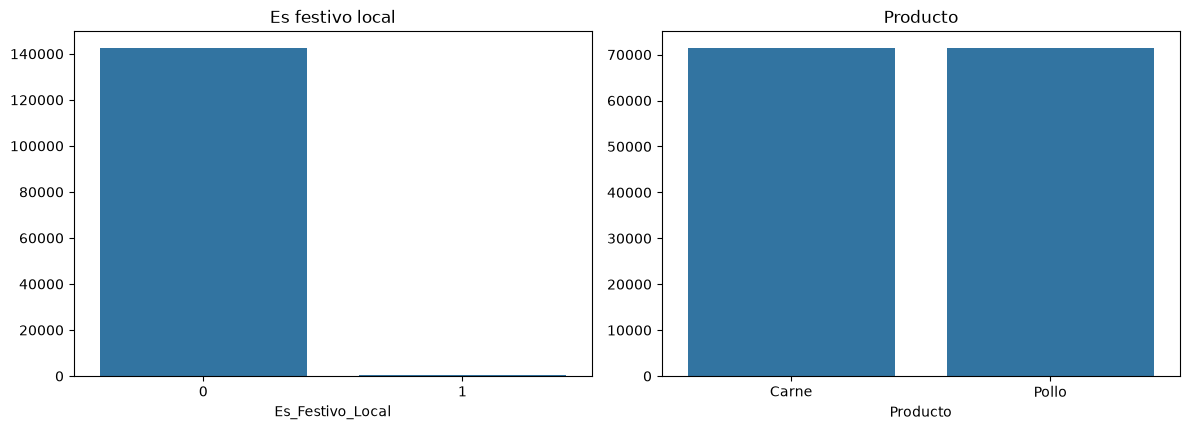

'\nAl ver el histograma, se puede ver que la mayoria del tiempo no es festivo\nPor lo que tambien podemos eliminar esta columna porque no representa mucho\n'

In [40]:
#Analsis univariate variable
#Analisis de variables categoricas, (variable que tiene un limite de numero por categoria)
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(2, 2, figsize=(12, 8))

sns.countplot(ax=axis[0,0], data=NewDf, x="Es_Festivo_Local").set(ylabel=None)
axis[0,0].set_title("Es festivo local")

sns.countplot(ax=axis[0,1], data=NewDf, x="Producto").set(ylabel=None)
axis[0,1].set_title("Producto")

for ax in axis.flat[2:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()
"""
Al ver el histograma, se puede ver que la mayoria del tiempo no es festivo
Por lo que tambien podemos eliminar esta columna porque no representa mucho
"""


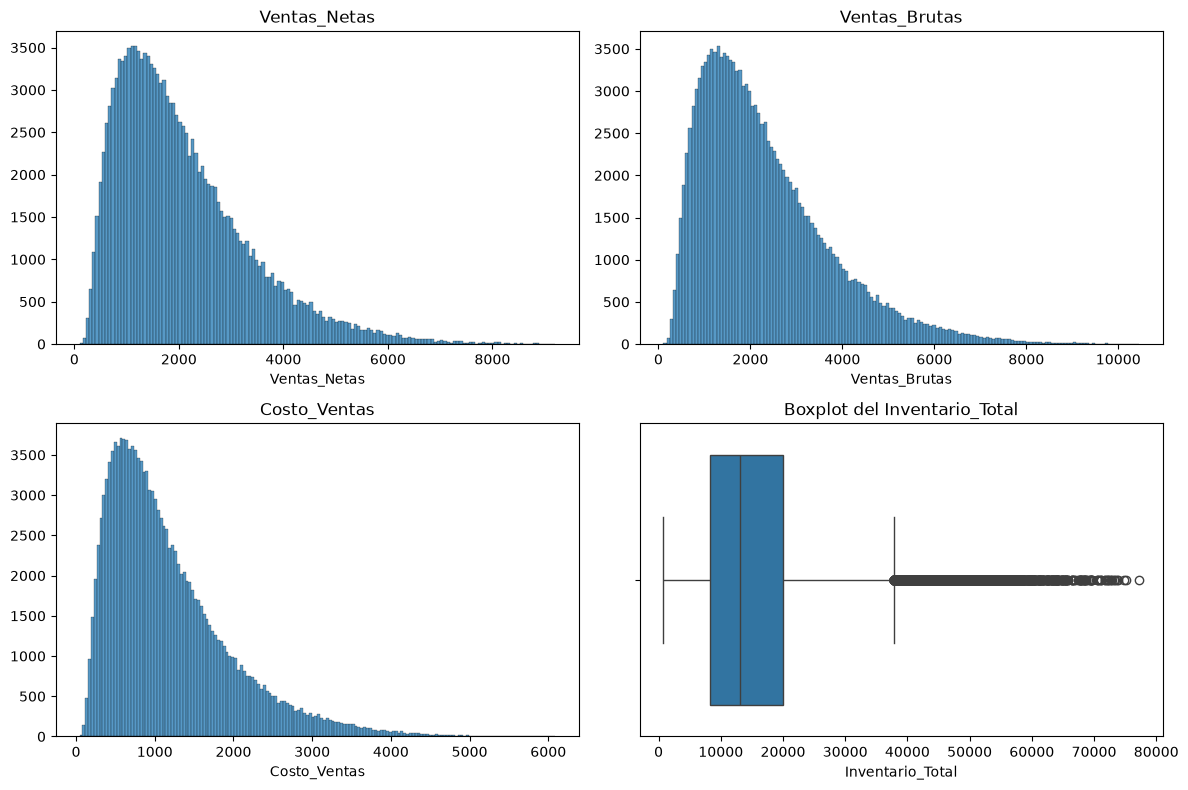

'\n\nExplicacion: Las ventas se ven en una distribucion sesgada a la derecha\npor lo que se estaria hablando de una distribucion asimetrica positiva\nel Skwe >0, el mismo caso se ve para las ventas brutas.\nMismo caso con el costo de ventas. El Inventario total tiene ciertos\noutliner, de casi 80000\n\n'

In [41]:
#Analsis de variables numericas
"""
En este caso tenemos las ventas, el costo, el inventario, etc

"""
import matplotlib.pyplot as plt
import seaborn as sns

#Crear histogramas y un diagrama de caja
fig, axis = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(ax=axis[0,0], data=NewDf, x="Ventas_Netas").set(ylabel=None)
axis[0,0].set_title("Ventas_Netas")

sns.histplot(ax=axis[0,1], data=NewDf, x="Ventas_Brutas").set(ylabel=None)
axis[0,1].set_title("Ventas_Brutas")

sns.histplot(ax=axis[1,0], data=NewDf, x="Costo_Ventas").set(ylabel=None)
axis[1,0].set_title("Costo_Ventas")


sns.boxplot(ax=axis[1,1], data= NewDf, x="Inventario_Total")
axis[1,1].set_title("Boxplot del Inventario_Total")


plt.tight_layout()
plt.show()

NewDf['Ventas_Netas'].skew()

"""

Explicacion: Las ventas se ven en una distribucion sesgada a la derecha
por lo que se estaria hablando de una distribucion asimetrica positiva
el Skwe >0, el mismo caso se ve para las ventas brutas.
Mismo caso con el costo de ventas. El Inventario total tiene ciertos
outliner, de casi 80000

"""

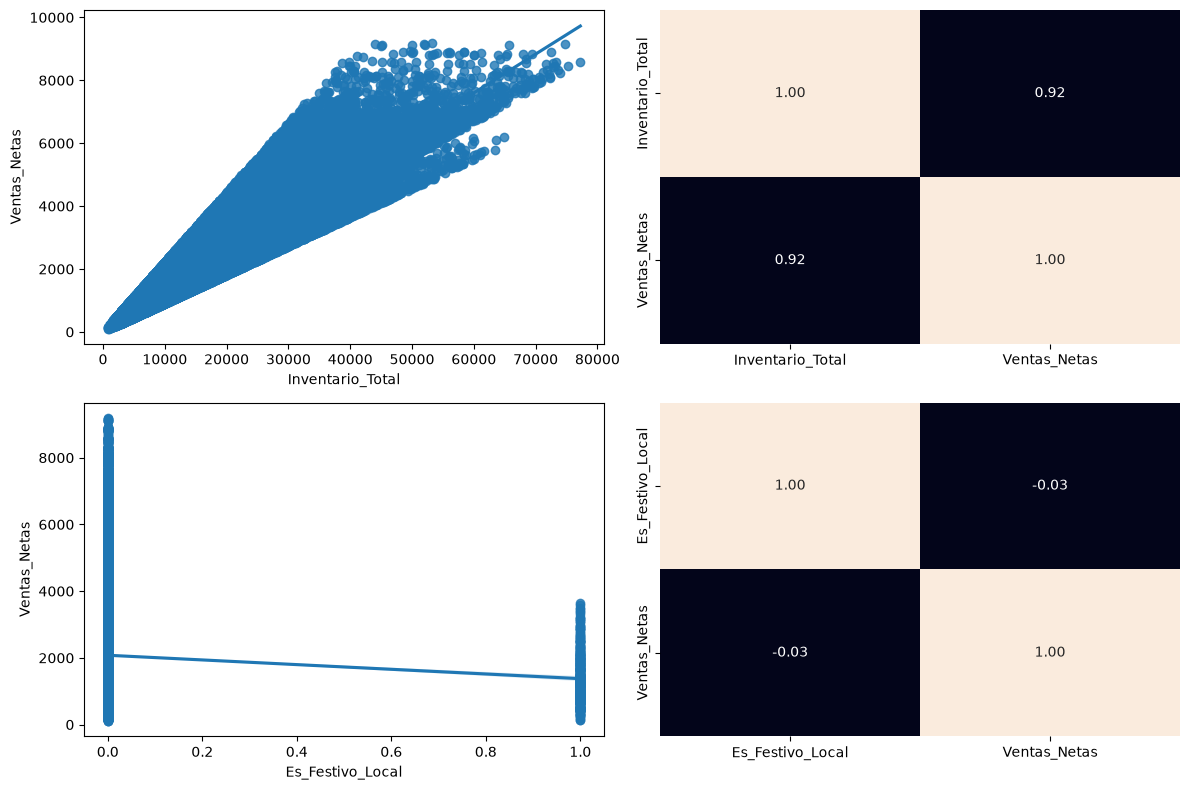

'\nLa corrlacion de las ventas y el inventario es 0.92(es muy alta)\nLa correlacion de las ventas con el festivo es -0.03(casi nula)\n'

In [42]:
#Analsis de multivariables
"""
Vamos a ver la relacion que tienen las ventas, el costo y el inventario
En este caso, lo vamos a ser numerico
"""
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(2, 2, figsize=(12, 8))

sns.regplot(ax=axis[0,0],data=NewDf, x="Inventario_Total", y="Ventas_Netas")

sns.heatmap(NewDf[["Inventario_Total","Ventas_Netas"]].corr(),annot=True,fmt=".2f",
            ax=axis[0,1], cbar=False)

sns.regplot(ax=axis[1,0],data=NewDf, x="Es_Festivo_Local", y="Ventas_Netas")

sns.heatmap(NewDf[["Es_Festivo_Local","Ventas_Netas"]].corr(),annot=True,fmt=".2f",
            ax=axis[1,1], cbar=False)


plt.tight_layout()
plt.show()
"""
Ventas e inventario estan fuertemente ligados, cuando las ventas aumentan
el inventario tambien aumenta. Sin embargo, los dias festivos no afentan 
a las ventas de forma relevante
"""
"""
La corrlacion de las ventas y el inventario es 0.92(es muy alta)
La correlacion de las ventas con el festivo es -0.03(casi nula)
"""



/tmp/ipykernel_18772/3378462482.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


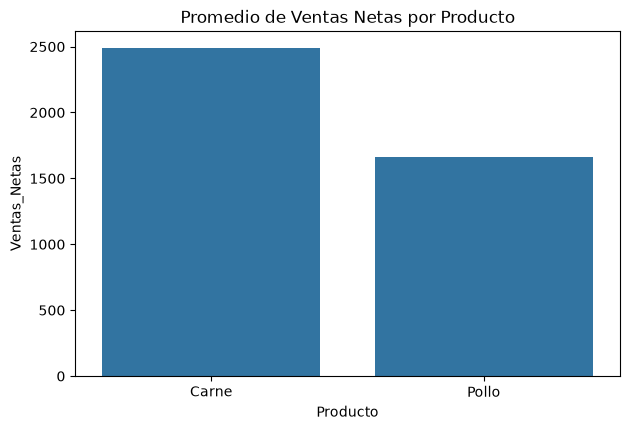

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(2, 2, figsize=(12, 8))

sns.barplot(
    ax=axis[0,0],
    data=NewDf,
    x="Producto",
    y="Ventas_Netas",
    estimator="mean",
    ci=None
)

axis[0,0].set_title("Promedio de Ventas Netas por Producto")

for ax in axis.flat[1:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


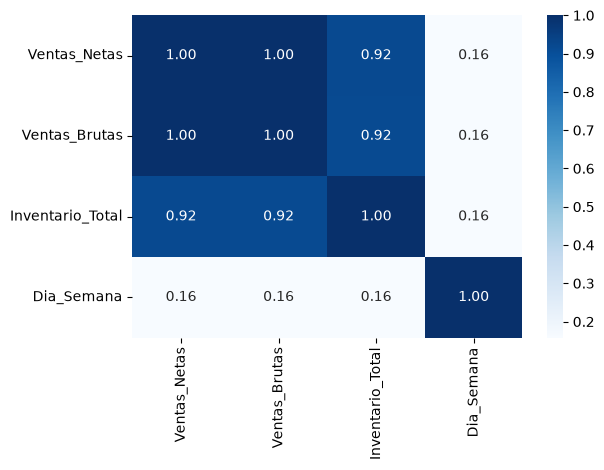

'\nNo se puede distingir una relacion clara entre las ventas y el dia\nde la semana \n\n'

In [44]:
#Numerical-categorical analysis

import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(
    NewDf[["Ventas_Netas","Ventas_Brutas","Inventario_Total","Dia_Semana"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.tight_layout()
plt.show()

"""
No se puede distingir una relacion clara entre las ventas y el dia
de la semana 

"""


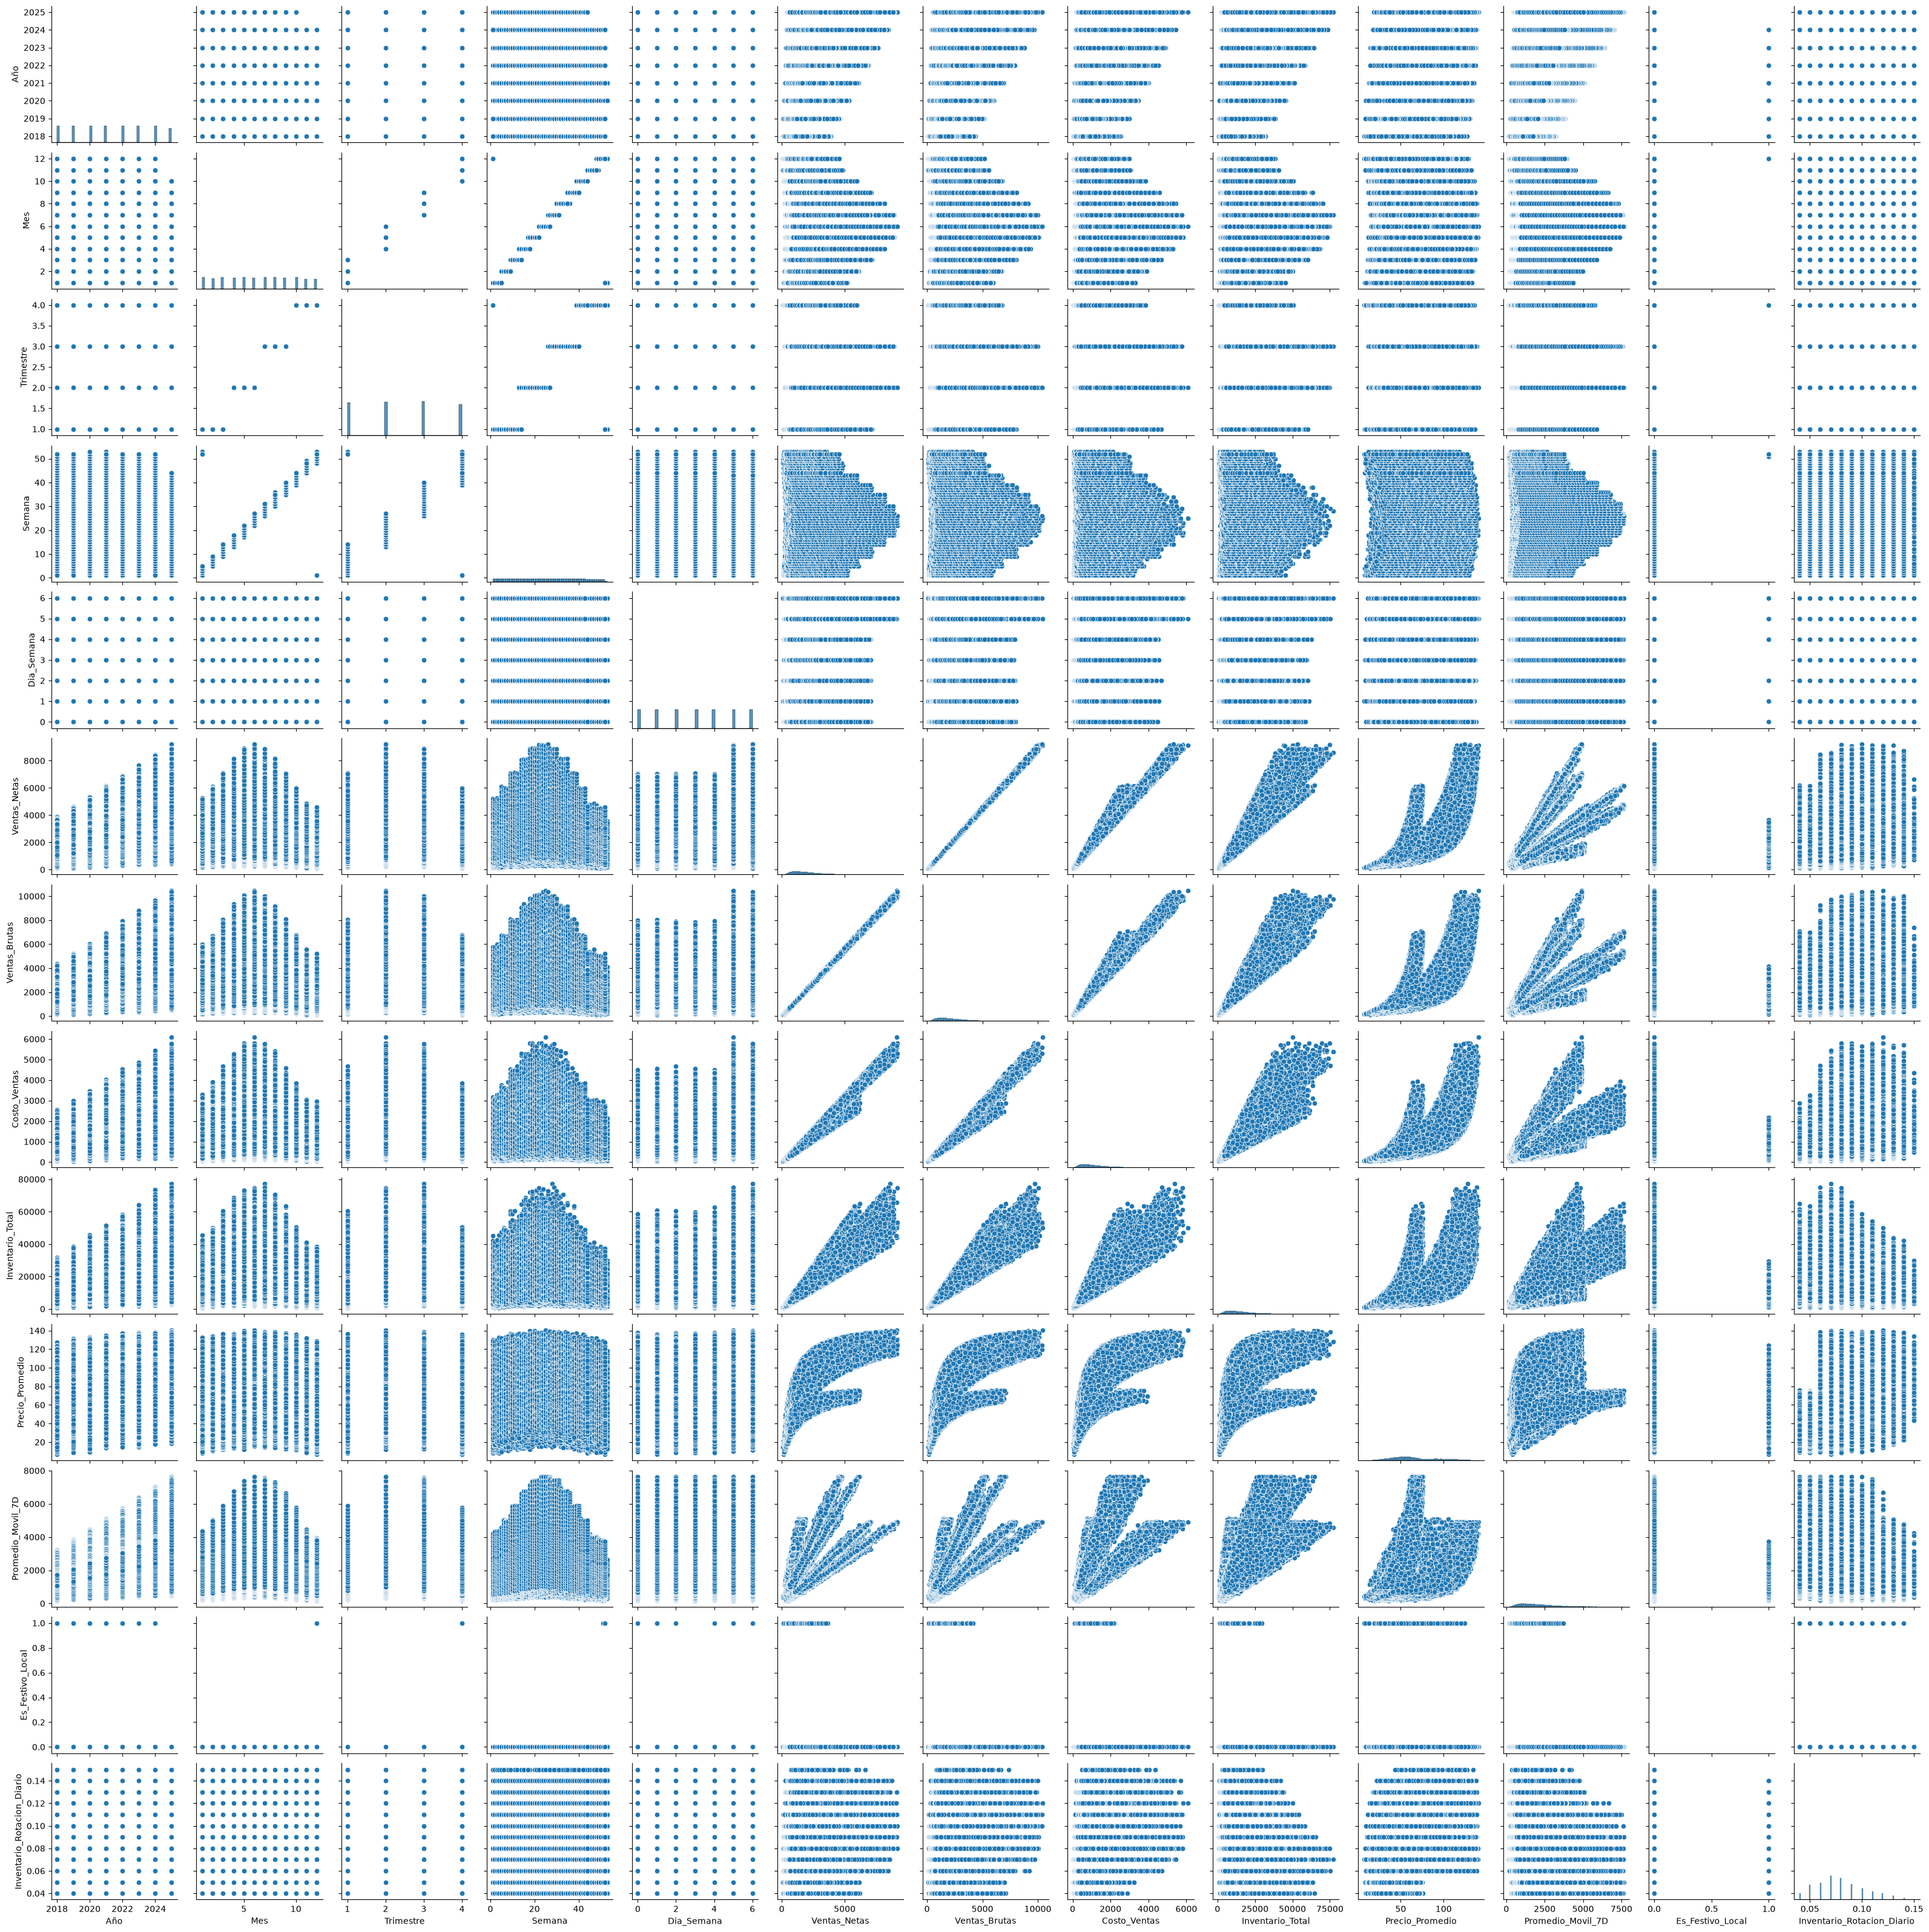

In [45]:
sns.pairplot(data=NewDf)

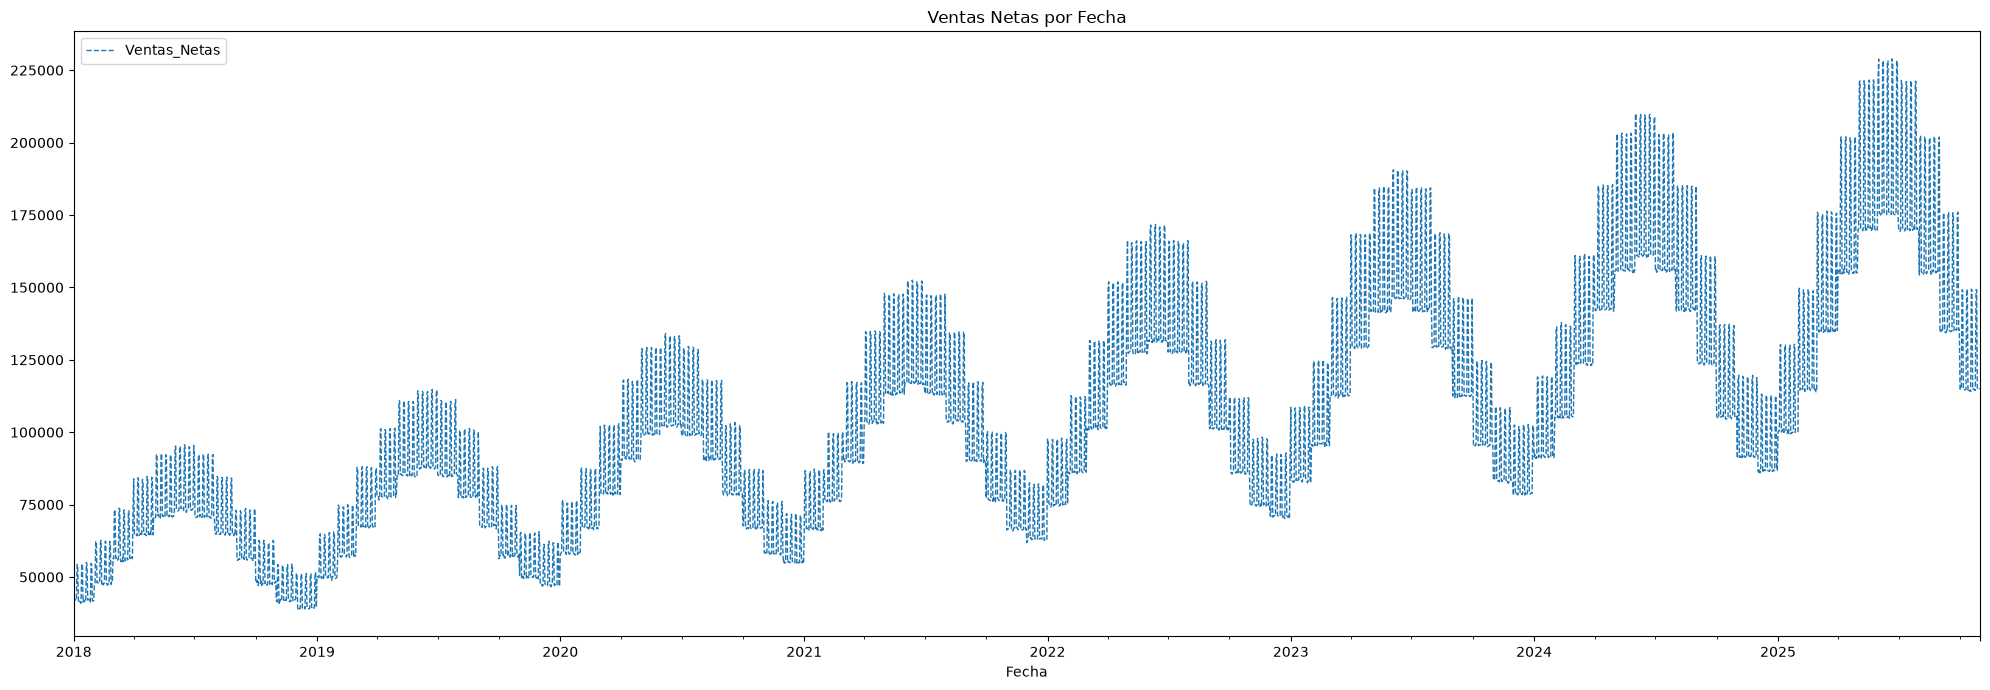

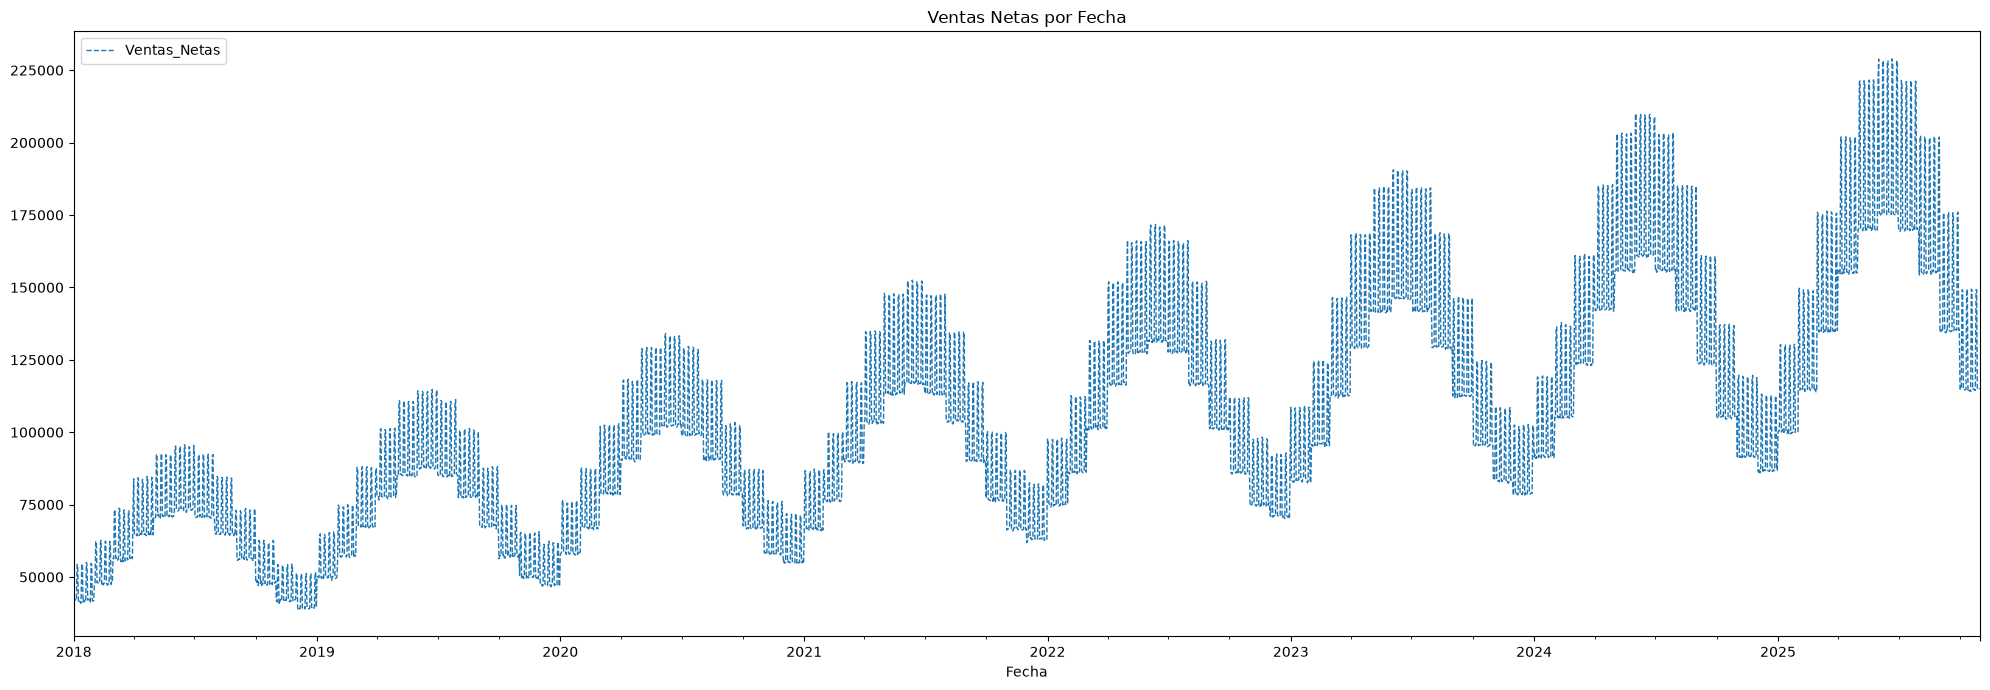

'\nLa gráfica muestra una estacionalidad donde se pueden ver los picos del año, aproximadamente a mitad del año, y además, se puede ver que tiene \nuna tendencia creciente, tal como se muestra, está lista para realizar un modelo de proyección.\n'

In [49]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit 
from sklearn.metrics import mean_squared_error 
from xgboost.callback import EarlyStopping
from pathlib import Path
import matplotlib.pyplot as plt

# Serie de tiempo: Carga utilizando la ruta relativa a data/raw
archivo_path = Path('../data/raw/DATA 12.11.2025.csv')

# Lectura del CSV con encoding y separador seguro
Df = pd.read_csv(archivo_path, encoding='latin-1', sep=None, engine='python')

# Eliminación segura de columnas
NewDf = Df.drop(["Transacciones_Count", "Ventas_Lag_7D", "Indicador_Economico_Local",
                 "Gasto_Marketing_Dia", "Margen_Bruto"], axis=1, errors='ignore')

# Convertir a datetime indicando que el día va primero
NewDf["Fecha"] = pd.to_datetime(NewDf["Fecha"], dayfirst=True, format='mixed')

# Agrupación y gráfico de serie temporal
counts = NewDf.groupby("Fecha")["Ventas_Netas"].sum()
pw_clean = pd.DataFrame(counts)
pw_clean["Fecha"] = pd.to_datetime(pw_clean.index)
pw_clean = pw_clean.set_index("Fecha")

pw_clean.plot(style="--", figsize=(20,7), lw=1, title="Ventas Netas por Fecha")
plt.tight_layout()
plt.show()

pw_clean.plot(style="--", figsize=(20,7), lw=1, title="Ventas Netas por Fecha")
plt.tight_layout()
plt.show()

"""
La gráfica muestra una estacionalidad donde se pueden ver los picos del año, aproximadamente a mitad del año, y además, se puede ver que tiene 
una tendencia creciente, tal como se muestra, está lista para realizar un modelo de proyección.
"""

[0]	validation_0-rmse:5112.52842	validation_1-rmse:6783.76883
[100]	validation_0-rmse:5.81183	validation_1-rmse:2660.69047
[131]	validation_0-rmse:2.20425	validation_1-rmse:2660.98204
Fold 1 → RMSE: 2,660 | R²: 0.9006
[0]	validation_0-rmse:5723.75392	validation_1-rmse:13058.50519
[77]	validation_0-rmse:47.45879	validation_1-rmse:4349.11388
Fold 2 → RMSE: 4,335 | R²: 0.8293
[0]	validation_0-rmse:7885.30442	validation_1-rmse:12119.77352
[100]	validation_0-rmse:61.10159	validation_1-rmse:2438.75479
[187]	validation_0-rmse:17.16762	validation_1-rmse:2435.93552
Fold 3 → RMSE: 2,434 | R²: 0.9597
[0]	validation_0-rmse:8833.59659	validation_1-rmse:18493.77570
[76]	validation_0-rmse:145.49153	validation_1-rmse:4880.45115
Fold 4 → RMSE: 4,877 | R²: 0.8802

RMSE por fold: ['2,660', '4,335', '2,434', '4,877']
RMSE promedio: 3,577
R² promedio: 0.8924


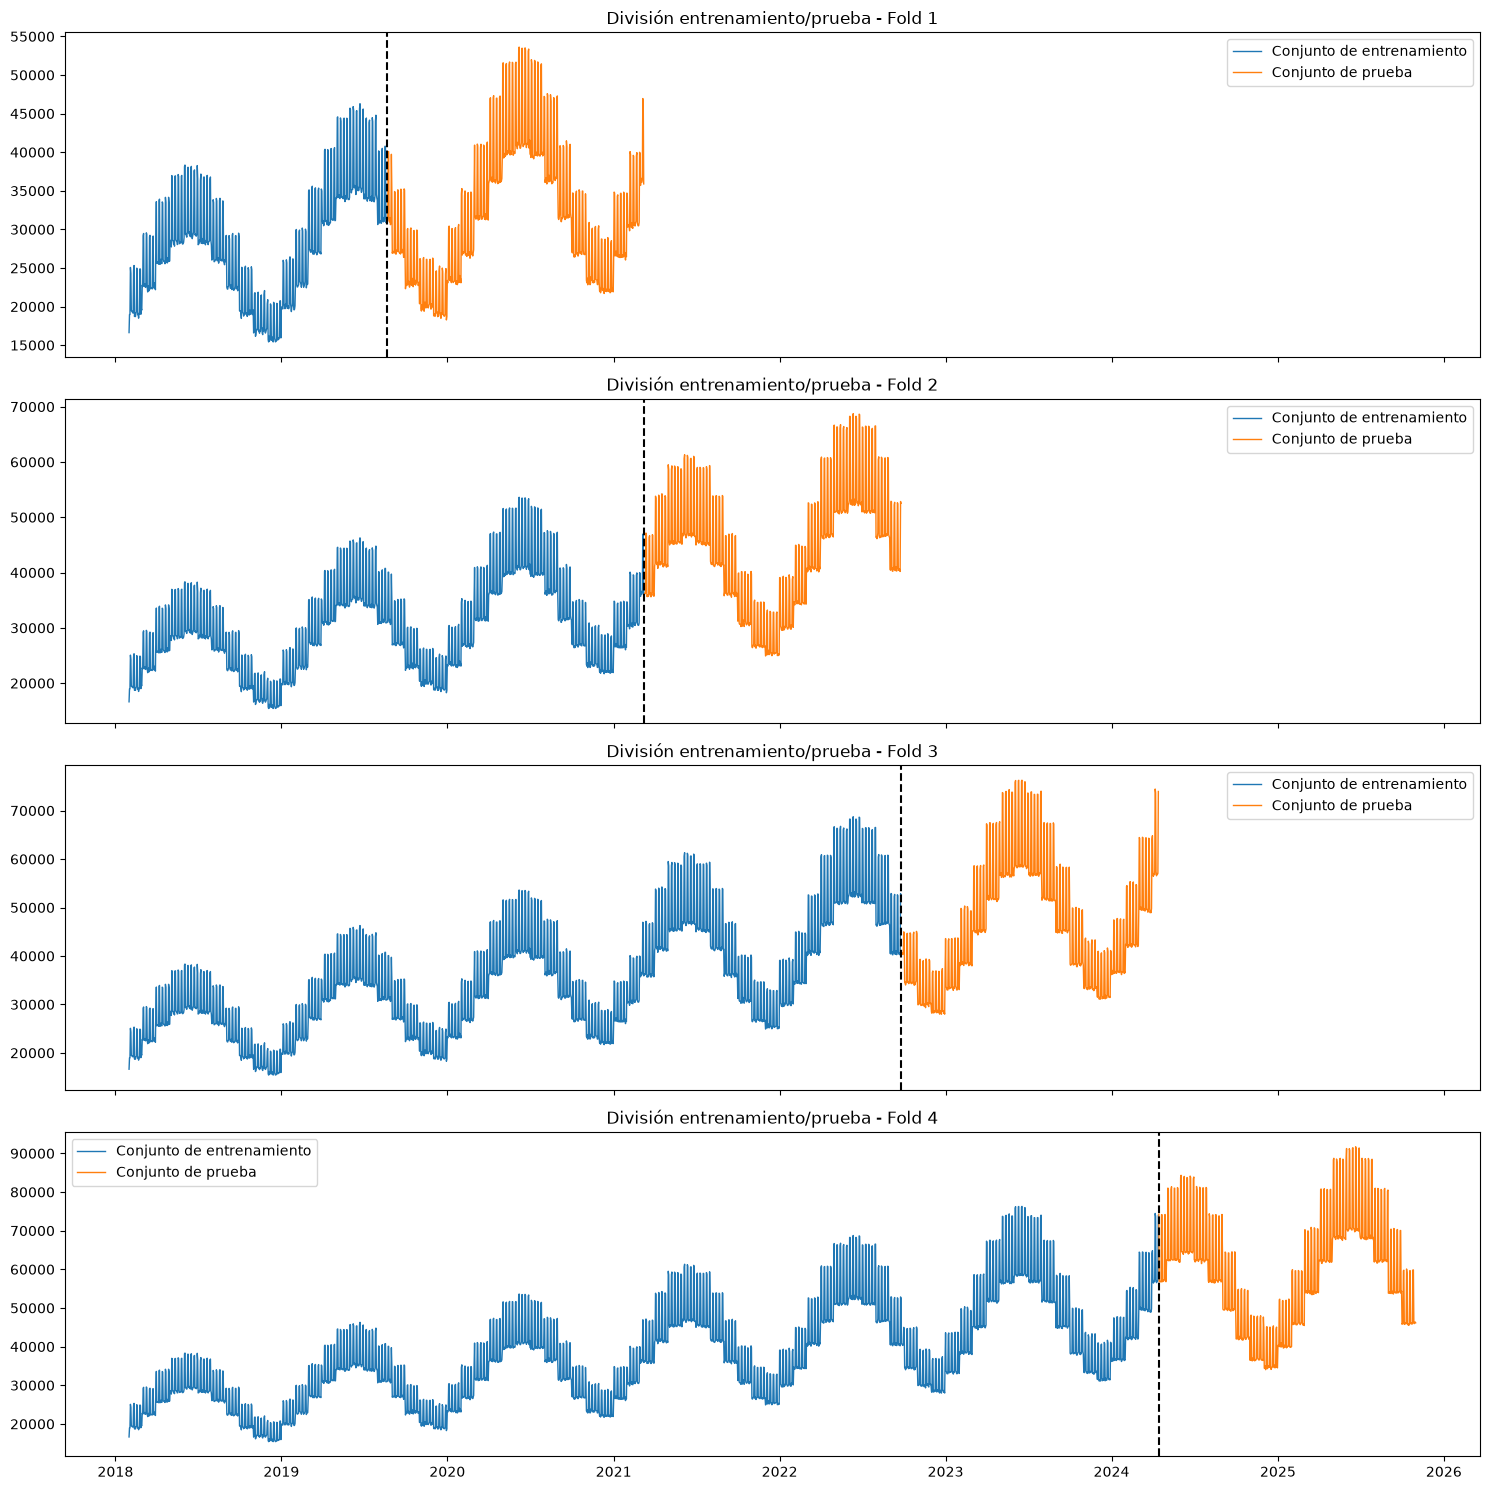

In [51]:
import pandas as pd
import sklearn as skl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import XGBRegressor
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit 
from sklearn.metrics import mean_squared_error, r2_score
from xgboost.callback import EarlyStopping

# Usar el dataframe ya cargado previamente y asegurar formato datetime correcto
NewDf["Fecha"] = pd.to_datetime(NewDf["Fecha"], dayfirst=True, format='mixed')

# Modelo del pollo
df_pollo = NewDf[NewDf["Producto"] == "Pollo"].copy()
counts = df_pollo.groupby("Fecha")["Ventas_Netas"].sum()
pw_clean = pd.DataFrame(counts)
pw_clean["Fecha"] = pd.to_datetime(pw_clean.index)
pw_clean = pw_clean.set_index("Fecha")

# Crear atributos temporales
def create_attributes(df): 
    df = df.copy() 
    df['día'] = df.index.day 
    df['díadelasemana'] = df.index.dayofweek 
    df['mes'] = df.index.month 
    df['trimestre'] = df.index.quarter 
    df['año'] = df.index.year 
    df['díadelaño'] = df.index.dayofyear 
    return df 

# Crear variables de rezago (lags) y promedios móviles
def add_lag_features(df, target='Ventas_Netas', lags=[1,7,14,30]):
    df = df.copy()
    for lag in lags:
        df[f'{target}_lag{lag}'] = df[target].shift(lag)
    df[f'{target}_rolling7']  = df[target].shift(1).rolling(7).mean()
    df[f'{target}_rolling30'] = df[target].shift(1).rolling(30).mean()
    return df

pw_clean = create_attributes(pw_clean)
pw_clean = add_lag_features(pw_clean)
pw_clean = pw_clean.dropna()
pw_clean = pw_clean.sort_index()

# Validación Cruzada de Series de Tiempo
ts_cv = TimeSeriesSplit(n_splits=4)
fold = 0
preds = []
scores = []
r2_scores = []

# Incluir las variables de ingeniería de características creadas
features = [
    'día', 'díadelasemana', 'mes', 'trimestre', 'año', 'díadelaño',
    'Ventas_Netas_lag1', 'Ventas_Netas_lag7', 'Ventas_Netas_lag14', 'Ventas_Netas_lag30',
    'Ventas_Netas_rolling7', 'Ventas_Netas_rolling30'
]
target = 'Ventas_Netas'

for train_idx, val_idx in ts_cv.split(pw_clean):
    fold += 1
    train = pw_clean.iloc[train_idx].copy()
    test  = pw_clean.iloc[val_idx].copy()

    x_train = train[features]
    y_train = train[target].values.ravel()  
    x_test  = test[features]
    y_test  = test[target].values.ravel()   

    # Hiperparámetros de XGBoost
    xgb_reg = xgb.XGBRegressor(
        booster='gbtree',
        random_state=42,
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.3,  
        reg_lambda=0.001,
        objective='reg:squarederror',
        eval_metric='rmse',
        early_stopping_rounds=50  
    )
    
    xgb_reg.fit(
        x_train, y_train,
        eval_set=[(x_train, y_train), (x_test, y_test)],
        verbose=100
    )
    
    # Métricas
    y_pred = xgb_reg.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(rmse)
    preds.append(y_pred)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    print(f"Fold {fold} → RMSE: {rmse:,.0f} | R²: {r2:.4f}")

print("\nRMSE por fold:", [f"{s:,.0f}" for s in scores])
print(f"RMSE promedio: {np.mean(scores):,.0f}")
print(f"R² promedio: {np.mean(r2_scores):.4f}")

# Gráfico de los Folds
fig, axs = plt.subplots(4, 1, figsize=(15, 15), sharex=True) 
fold = 0
for train_idx, val_idx in ts_cv.split(pw_clean):
    train = pw_clean.iloc[train_idx]
    test  = pw_clean.iloc[val_idx]

    axs[fold].plot(train.index, train["Ventas_Netas"], lw=1, label="Conjunto de entrenamiento")
    axs[fold].plot(test.index, test["Ventas_Netas"], lw=1, label="Conjunto de prueba")
    axs[fold].axvline(test.index.min(), color="black", ls="--") 
    axs[fold].set_title(f"División entrenamiento/prueba - Fold {fold + 1}") 
    axs[fold].legend()
    fold += 1

plt.tight_layout()
plt.show()

Fold 1 → RMSE: 3,444 | R²: 0.7783
Fold 2 → RMSE: 3,704 | R²: 0.8553
Fold 3 → RMSE: 3,089 | R²: 0.9152
Fold 4 → RMSE: 2,448 | R²: 0.9408
Fold 5 → RMSE: 3,782 | R²: 0.8730
Fold 6 → RMSE: 4,971 | R²: 0.8365
Fold 7 → RMSE: 3,640 | R²: 0.9213
Fold 8 → RMSE: 5,067 | R²: 0.8699

RMSE por fold: ['3,444', '3,704', '3,089', '2,448', '3,782', '4,971', '3,640', '5,067']
RMSE promedio: 3,768
R² promedio: 0.8738


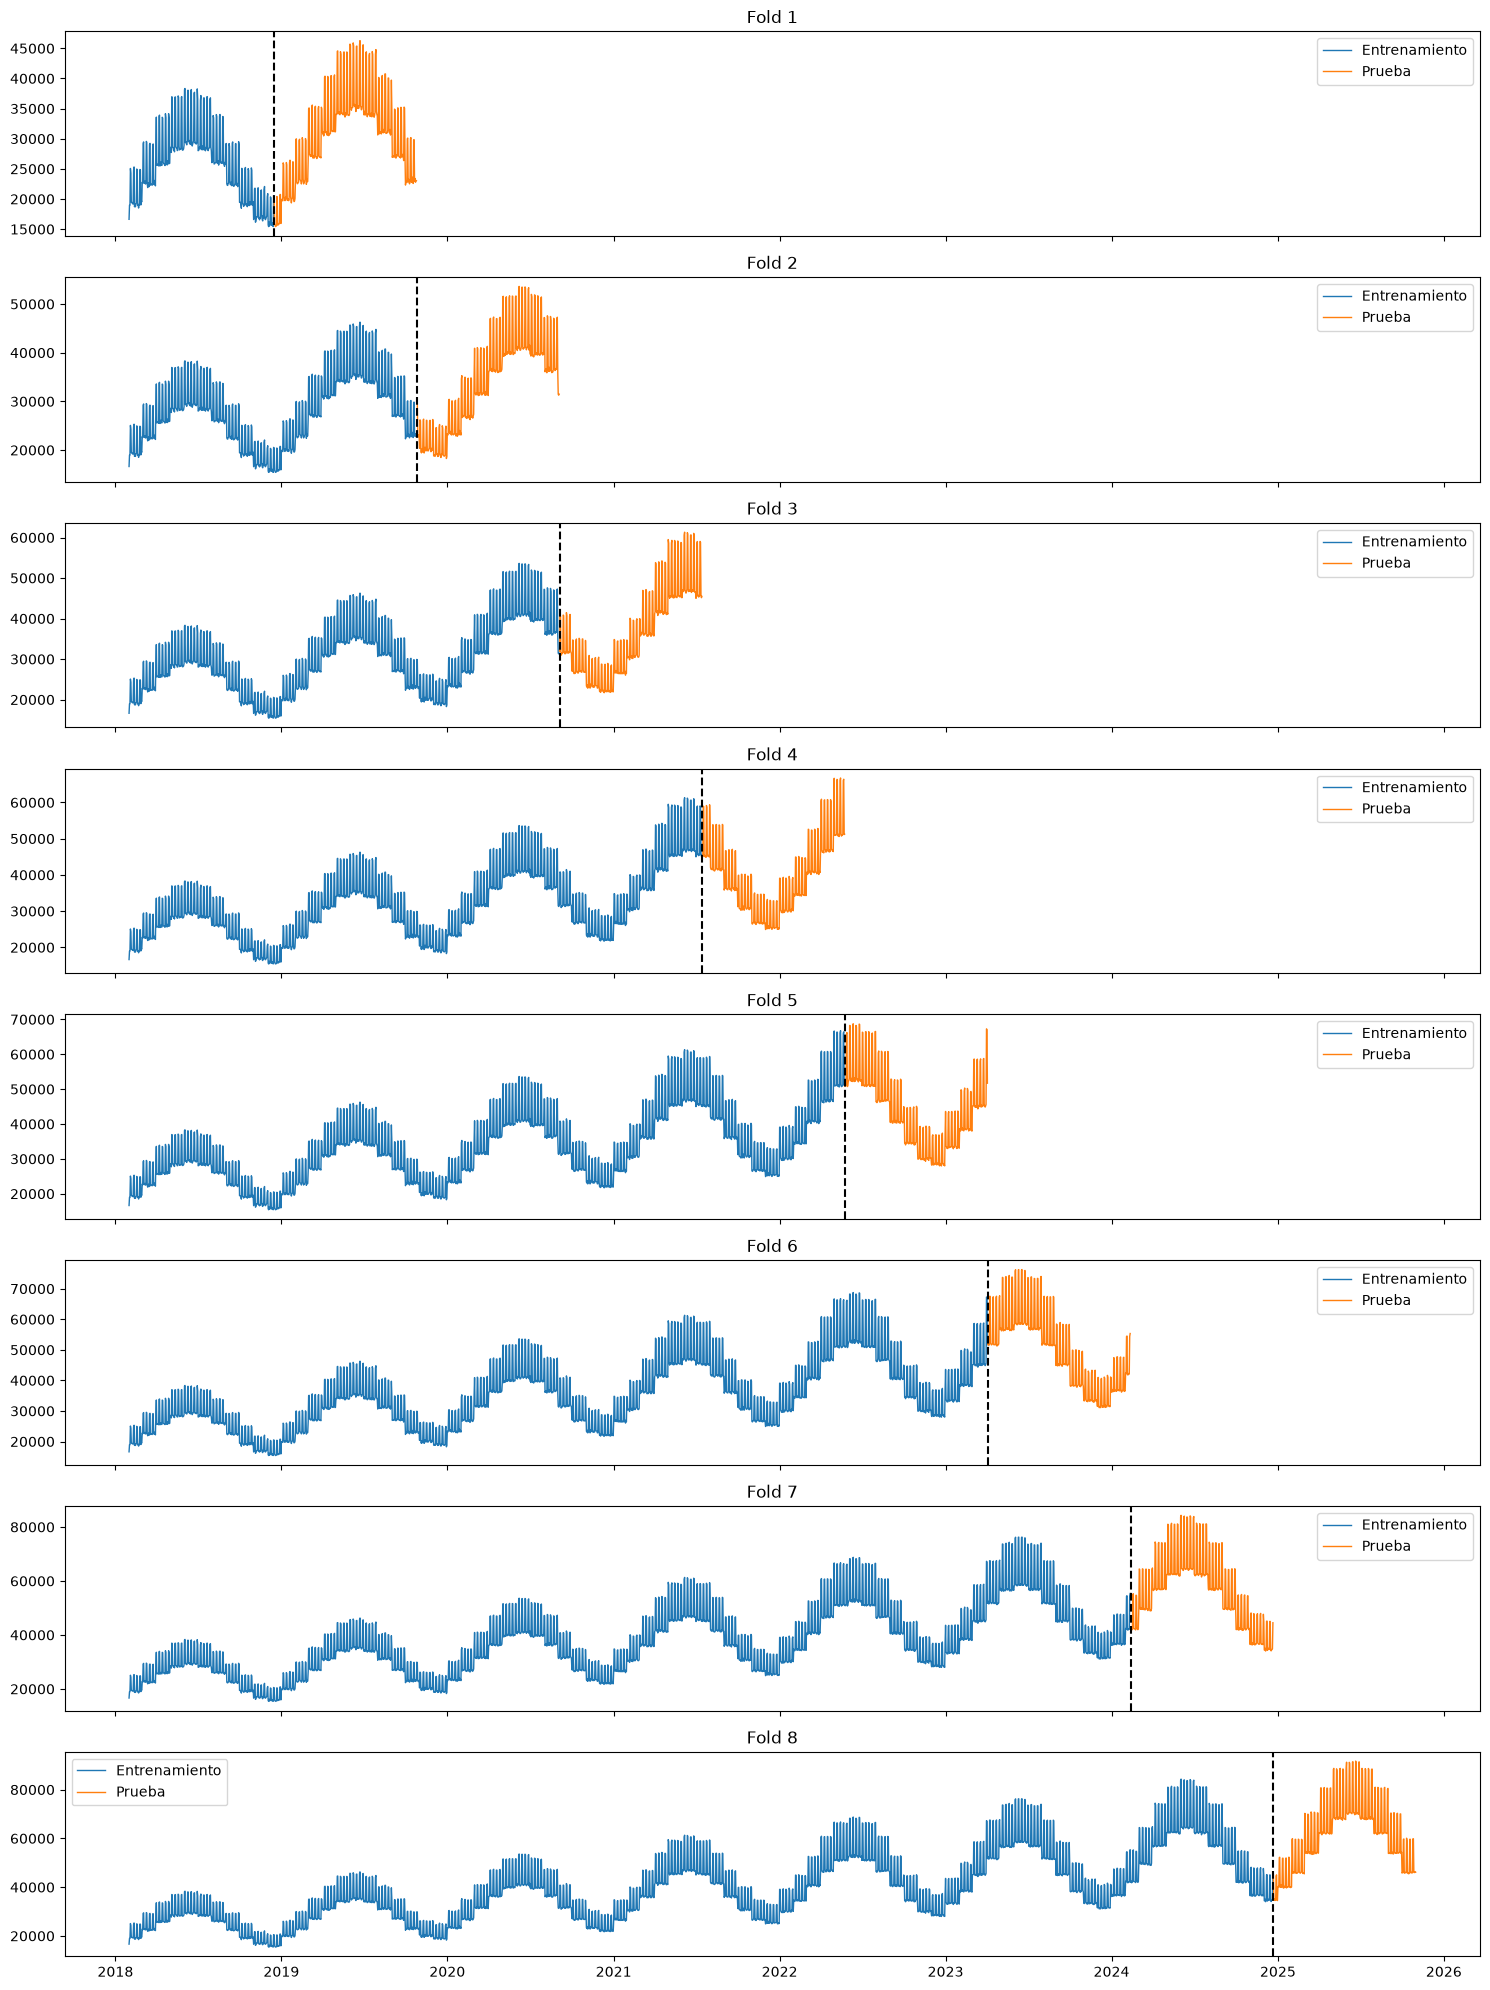

In [53]:
#Ahora vamos a cambiarle los hiperparametros para saber si hay una mejora con el R2 debido que el primero fue 0.6
#el cual, no es malo, pero se puede mejorar
# Optimización de hiperparámetros para mejorar R2
import pandas as pd
import sklearn as skl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import XGBRegressor
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit 
from sklearn.metrics import mean_squared_error, r2_score
from xgboost.callback import EarlyStopping

# Asegurar tipo datetime usando el dataframe en memoria
NewDf["Fecha"] = pd.to_datetime(NewDf["Fecha"], dayfirst=True, format='mixed')

# Modelo del pollo
df_pollo = NewDf[NewDf["Producto"] == "Pollo"].copy()
counts = df_pollo.groupby("Fecha")["Ventas_Netas"].sum()
pw_clean = pd.DataFrame(counts)
pw_clean["Fecha"] = pd.to_datetime(pw_clean.index)
pw_clean = pw_clean.set_index("Fecha")

# Crear los atributos de las fechas
def create_attributes(df): 
    df = df.copy() 
    df['día'] = df.index.day 
    df['díadelasemana'] = df.index.dayofweek 
    df['mes'] = df.index.month 
    df['trimestre'] = df.index.quarter 
    df['año'] = df.index.year 
    df['díadelaño'] = df.index.dayofyear 
    return df 

def add_lag_features(df, target='Ventas_Netas', lags=[1,7,14,30]):
    df = df.copy()
    for lag in lags:
        df[f'{target}_lag{lag}'] = df[target].shift(lag)
    df[f'{target}_rolling7']  = df[target].shift(1).rolling(7).mean()
    df[f'{target}_rolling30'] = df[target].shift(1).rolling(30).mean()
    return df

pw_clean = create_attributes(pw_clean)
pw_clean = add_lag_features(pw_clean)
pw_clean = pw_clean.dropna()
pw_clean = pw_clean.sort_index()

# TimeSeriesSplit con 8 splits
ts_cv = TimeSeriesSplit(n_splits=8)
fold = 0
preds = []
scores = []
r2_scores = []

# Incluimos las variables de lag y rolling creadas para que el modelo capture el patrón temporal
features = [
    'día', 'díadelasemana', 'mes', 'trimestre', 'año', 'díadelaño',
    'Ventas_Netas_lag1', 'Ventas_Netas_lag7', 'Ventas_Netas_lag14', 'Ventas_Netas_lag30',
    'Ventas_Netas_rolling7', 'Ventas_Netas_rolling30'
]
target = 'Ventas_Netas'

for train_idx, val_idx in ts_cv.split(pw_clean):
    fold += 1
    train = pw_clean.iloc[train_idx].copy()
    test  = pw_clean.iloc[val_idx].copy()

    x_train = train[features]
    y_train = train[target].values.ravel()  
    x_test  = test[features]
    y_test  = test[target].values.ravel()   

    # Hiperparámetros ajustados (max_depth=12)
    xgb_reg = xgb.XGBRegressor(
        booster='gbtree',
        random_state=42,
        n_estimators=1000,
        max_depth=12,
        learning_rate=0.3,  
        reg_lambda=0.001,
        objective='reg:squarederror',
        eval_metric='rmse',
        early_stopping_rounds=50  
    )
    
    xgb_reg.fit(
        x_train, y_train,
        eval_set=[(x_train, y_train), (x_test, y_test)],
        verbose=False
    )
    
    # Métricas
    y_pred = xgb_reg.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(rmse)
    preds.append(y_pred)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    print(f"Fold {fold} → RMSE: {rmse:,.0f} | R²: {r2:.4f}")

print("\nRMSE por fold:", [f"{s:,.0f}" for s in scores])
print(f"RMSE promedio: {np.mean(scores):,.0f}")
print(f"R² promedio: {np.mean(r2_scores):.4f}")

# Gráfico de los 8 Folds
fig, axs = plt.subplots(8, 1, figsize=(15, 20), sharex=True) 
fold = 0
for train_idx, val_idx in ts_cv.split(pw_clean):
    train = pw_clean.iloc[train_idx]
    test  = pw_clean.iloc[val_idx]

    axs[fold].plot(train.index, train["Ventas_Netas"], lw=1, label="Entrenamiento")
    axs[fold].plot(test.index, test["Ventas_Netas"], lw=1, label="Prueba")
    axs[fold].axvline(test.index.min(), color="black", ls="--") 
    axs[fold].set_title(f"Fold {fold + 1}") 
    axs[fold].legend()
    fold += 1

plt.tight_layout()
plt.show()

Fold 1 → RMSE: 5,083 | R²: 0.7841
Fold 2 → RMSE: 5,447 | R²: 0.8610
Fold 3 → RMSE: 5,804 | R²: 0.8666
Fold 4 → RMSE: 4,203 | R²: 0.9227
Fold 5 → RMSE: 5,721 | R²: 0.8716
Fold 6 → RMSE: 7,601 | R²: 0.8303
Fold 7 → RMSE: 5,268 | R²: 0.9268
Fold 8 → RMSE: 7,757 | R²: 0.8647

RMSE por fold: ['5,083', '5,447', '5,804', '4,203', '5,721', '7,601', '5,268', '7,757']
RMSE promedio: 5,861
R² promedio: 0.8660


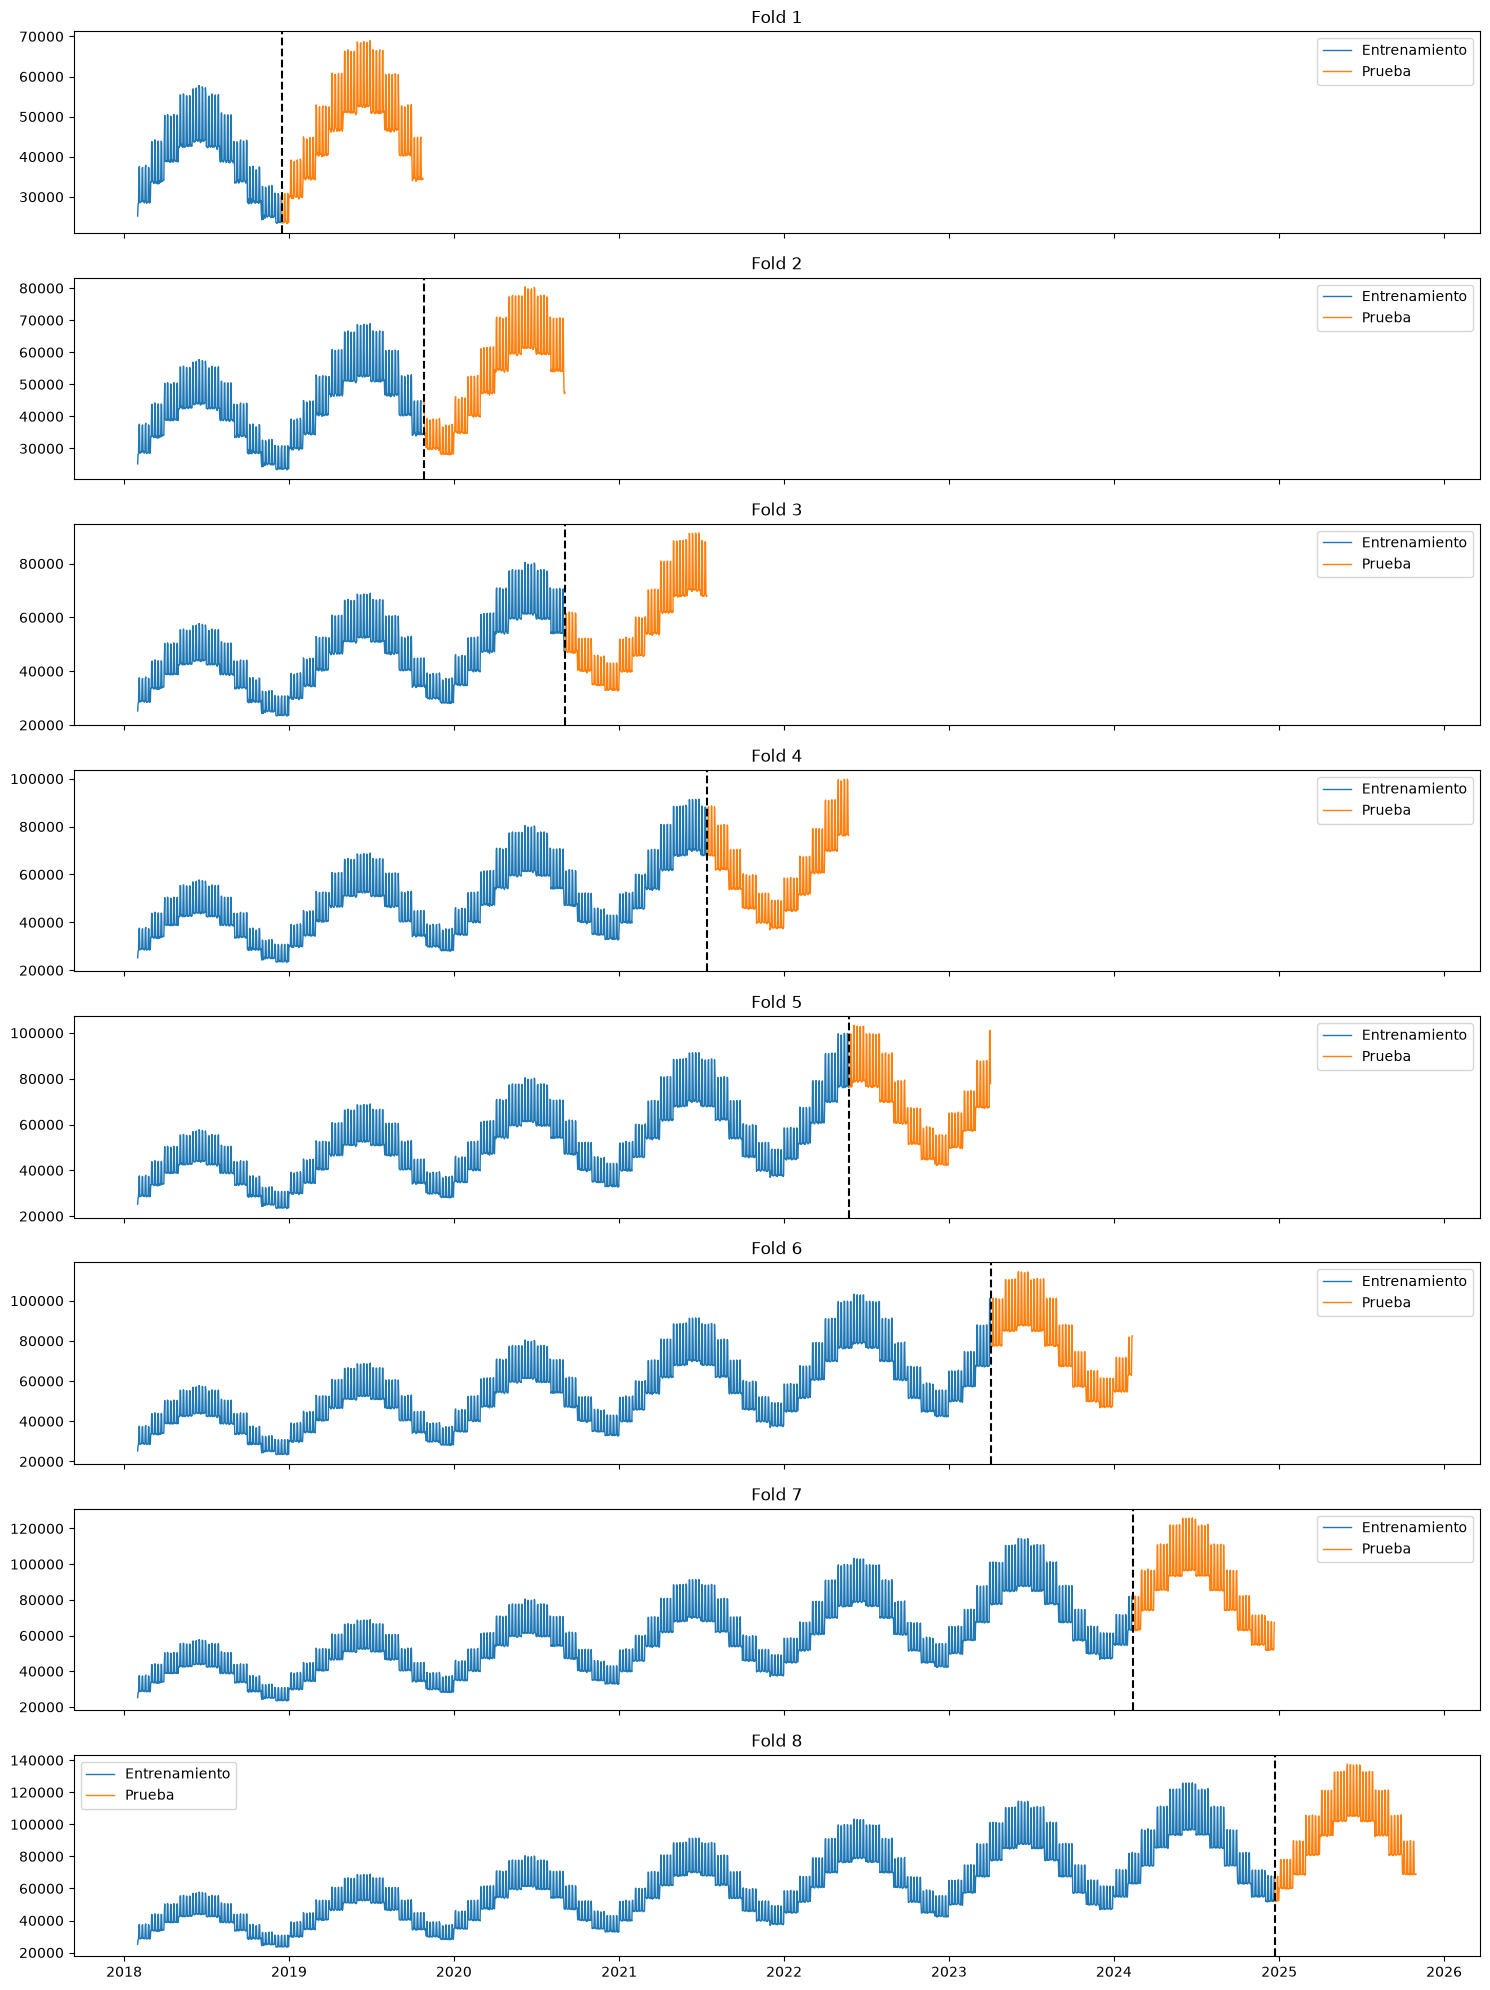

In [55]:
# Modelo de Carne con optimización de hiperparámetros e inclusión de Lags
import pandas as pd
import sklearn as skl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import XGBRegressor
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit 
from sklearn.metrics import mean_squared_error, r2_score
from xgboost.callback import EarlyStopping

# Usar directamente el NewDf en memoria y asegurar formato datetime
NewDf["Fecha"] = pd.to_datetime(NewDf["Fecha"], dayfirst=True, format='mixed')

# Filtrar para el producto "Carne"
df_carne = NewDf[NewDf["Producto"] == "Carne"].copy()
counts = df_carne.groupby("Fecha")["Ventas_Netas"].sum()
pw_clean = pd.DataFrame(counts)
pw_clean["Fecha"] = pd.to_datetime(pw_clean.index)
pw_clean = pw_clean.set_index("Fecha")

# Crear los atributos de las fechas
def create_attributes(df): 
    df = df.copy() 
    df['día'] = df.index.day 
    df['díadelasemana'] = df.index.dayofweek 
    df['mes'] = df.index.month 
    df['trimestre'] = df.index.quarter 
    df['año'] = df.index.year 
    df['díadelaño'] = df.index.dayofyear 
    return df 

def add_lag_features(df, target='Ventas_Netas', lags=[1,7,14,30]):
    df = df.copy()
    for lag in lags:
        df[f'{target}_lag{lag}'] = df[target].shift(lag)
    df[f'{target}_rolling7']  = df[target].shift(1).rolling(7).mean()
    df[f'{target}_rolling30'] = df[target].shift(1).rolling(30).mean()
    return df

pw_clean = create_attributes(pw_clean)
pw_clean = add_lag_features(pw_clean)
pw_clean = pw_clean.dropna()
pw_clean = pw_clean.sort_index()

# TimeSeriesSplit con 8 splits
ts_cv = TimeSeriesSplit(n_splits=8)
fold = 0
preds = []
scores = []
r2_scores = []

# Incluimos las variables de lag y rolling para aprovechar la serie temporal
features = [
    'día', 'díadelasemana', 'mes', 'trimestre', 'año', 'díadelaño',
    'Ventas_Netas_lag1', 'Ventas_Netas_lag7', 'Ventas_Netas_lag14', 'Ventas_Netas_lag30',
    'Ventas_Netas_rolling7', 'Ventas_Netas_rolling30'
]
target = 'Ventas_Netas'

for train_idx, val_idx in ts_cv.split(pw_clean):
    fold += 1
    train = pw_clean.iloc[train_idx].copy()
    test  = pw_clean.iloc[val_idx].copy()

    x_train = train[features]
    y_train = train[target].values.ravel()  
    x_test  = test[features]
    y_test  = test[target].values.ravel()   

    # Hiperparámetros ajustados (max_depth=12)
    xgb_reg = xgb.XGBRegressor(
        booster='gbtree',
        random_state=42,
        n_estimators=1000,
        max_depth=12,
        learning_rate=0.3,  
        reg_lambda=0.001,
        objective='reg:squarederror',
        eval_metric='rmse',
        early_stopping_rounds=50  
    )
    
    xgb_reg.fit(
        x_train, y_train,
        eval_set=[(x_train, y_train), (x_test, y_test)],
        verbose=False
    )
    
    # Métricas
    y_pred = xgb_reg.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(rmse)
    preds.append(y_pred)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    print(f"Fold {fold} → RMSE: {rmse:,.0f} | R²: {r2:.4f}")

print("\nRMSE por fold:", [f"{s:,.0f}" for s in scores])
print(f"RMSE promedio: {np.mean(scores):,.0f}")
print(f"R² promedio: {np.mean(r2_scores):.4f}")

# Gráfico de los 8 Folds para Carne
fig, axs = plt.subplots(8, 1, figsize=(15, 20), sharex=True) 
fold = 0
for train_idx, val_idx in ts_cv.split(pw_clean):
    train = pw_clean.iloc[train_idx]
    test  = pw_clean.iloc[val_idx]

    axs[fold].plot(train.index, train["Ventas_Netas"], lw=1, label="Entrenamiento")
    axs[fold].plot(test.index, test["Ventas_Netas"], lw=1, label="Prueba")
    axs[fold].axvline(test.index.min(), color="black", ls="--") 
    axs[fold].set_title(f"Fold {fold + 1}") 
    axs[fold].legend()
    fold += 1

plt.tight_layout()
plt.show()


--- INICIO DEL ENTRENAMIENTO (8 Folds) ---


Fold 1 → RMSE: 5,088 | R²: 0.7837
Fold 2 → RMSE: 5,548 | R²: 0.8558
Fold 3 → RMSE: 6,062 | R²: 0.8545
Fold 4 → RMSE: 4,203 | R²: 0.9227
Fold 5 → RMSE: 6,157 | R²: 0.8512
Fold 6 → RMSE: 8,974 | R²: 0.7635
Fold 7 → RMSE: 5,268 | R²: 0.9268
Fold 8 → RMSE: 7,757 | R²: 0.8647

--- RESUMEN DE MÉTRICAS ---
RMSE promedio: 6,132
R² promedio: 0.8529


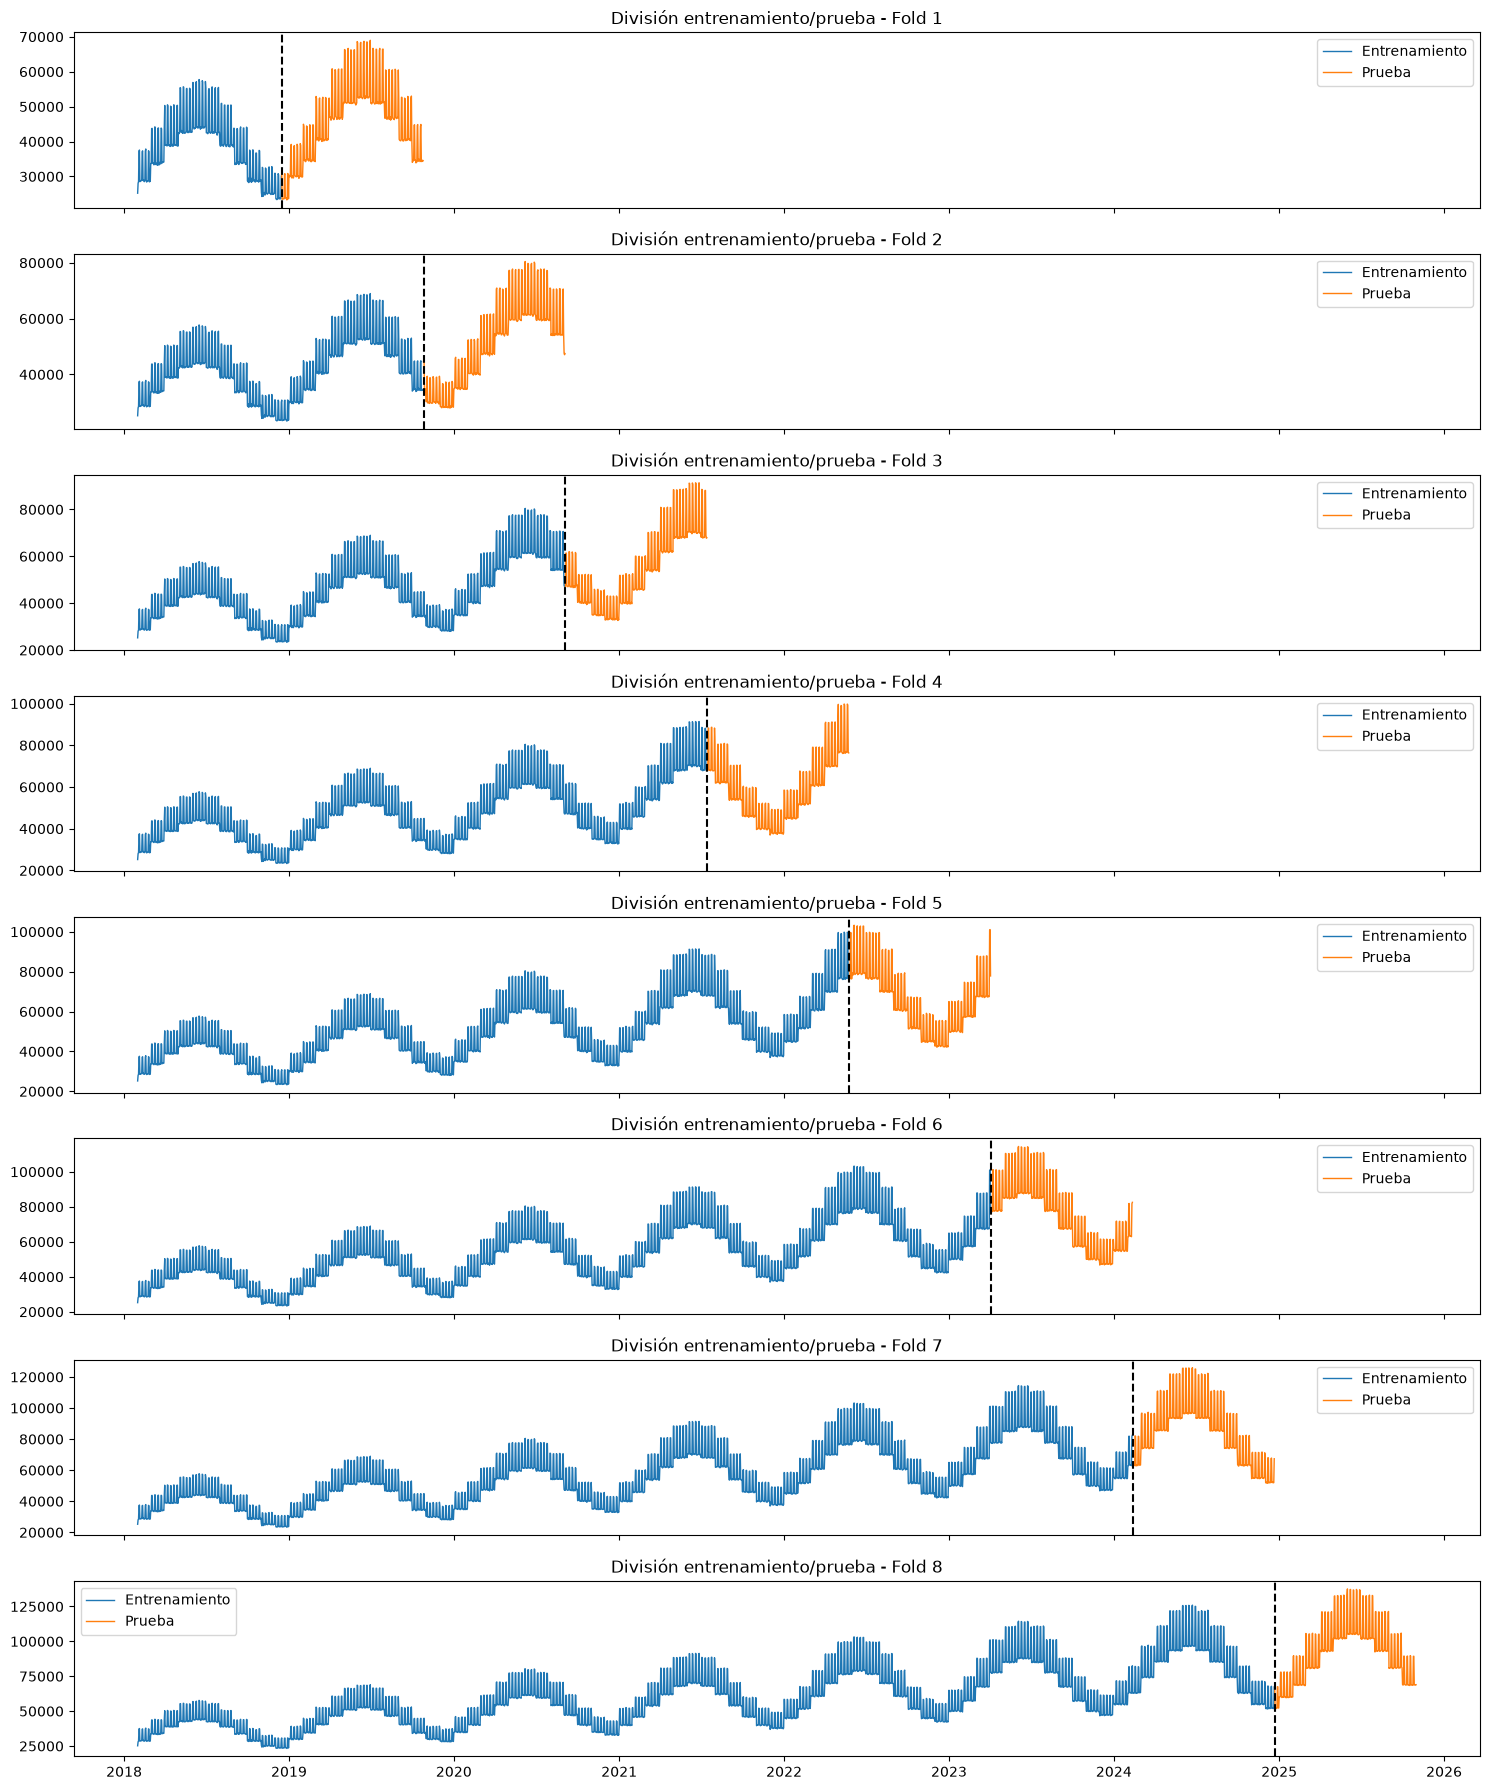


--- INICIO DE LA PREDICCIÓN A FUTURO ---

--- PREDICCIÓN FINAL DE VENTAS NETAS (Carne) ---
            Ventas_Netas_Predicha
Fecha                            
2025-11-01                81662.0
2025-11-02                81651.0
2025-11-03                65580.0
2025-11-04                65579.0
2025-11-05                65554.0
2025-11-06                65555.0
2025-11-07                64705.0


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import XGBRegressor
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit 
from sklearn.metrics import mean_squared_error, r2_score 
from datetime import timedelta

# --- 1. CONFIGURACIÓN Y USO DE DATOS EN MEMORIA ---

# Garantizar el formato correcto de fecha sobre el DataFrame activo
NewDf["Fecha"] = pd.to_datetime(NewDf["Fecha"], dayfirst=True, format='mixed')

# Filtrar para el producto "Carne"
df_carne = NewDf[NewDf["Producto"] == "Carne"].copy()
counts = df_carne.groupby("Fecha")["Ventas_Netas"].sum()
pw_clean = pd.DataFrame(counts)
pw_clean["Fecha"] = pd.to_datetime(pw_clean.index)
pw_clean = pw_clean.set_index("Fecha")

# --- 2. FUNCIONES DE INGENIERÍA DE ATRIBUTOS (FEATURE ENGINEERING) ---

def create_attributes(df): 
    """Crea atributos temporales (features) a partir del índice de fecha."""
    df = df.copy() 
    df['día'] = df.index.day 
    df['díadelasemana'] = df.index.dayofweek 
    df['mes'] = df.index.month 
    df['trimestre'] = df.index.quarter 
    df['año'] = df.index.year 
    df['díadelaño'] = df.index.dayofyear 
    return df 

def add_lag_features(df, target='Ventas_Netas', lags=[1, 7, 14, 30]):
    """Crea atributos de lag (retardo) y rolling mean."""
    df = df.copy()
    for lag in lags:
        df[f'{target}_lag{lag}'] = df[target].shift(lag)
    df[f'{target}_rolling7']  = df[target].shift(1).rolling(7).mean()
    df[f'{target}_rolling30'] = df[target].shift(1).rolling(30).mean()
    return df

# Aplicar ingeniería de atributos
pw_clean = create_attributes(pw_clean)
pw_clean = add_lag_features(pw_clean)
pw_clean = pw_clean.dropna()

features = ['día', 'díadelasemana', 'mes', 'trimestre', 'año', 'díadelaño',
            'Ventas_Netas_lag1', 'Ventas_Netas_lag7', 'Ventas_Netas_lag14', 'Ventas_Netas_lag30', 
            'Ventas_Netas_rolling7', 'Ventas_Netas_rolling30']
target = 'Ventas_Netas'

# --- 3. ENTRENAMIENTO Y VALIDACIÓN CON TIME SERIES SPLIT ---

pw_clean = pw_clean.sort_index()
ts_cv = TimeSeriesSplit(n_splits=8)

fold = 0
scores = []      # RMSE
r2_scores = []   # R-cuadrado

print("\n--- INICIO DEL ENTRENAMIENTO (8 Folds) ---")

for train_idx, val_idx in ts_cv.split(pw_clean):
    fold += 1
    train = pw_clean.iloc[train_idx].copy()
    test  = pw_clean.iloc[val_idx].copy()
    
    x_train = train[features]
    y_train = train[target].values.ravel()  
    x_test  = test[features]
    y_test  = test[target].values.ravel()   

    xgb_reg = xgb.XGBRegressor(
        booster='gbtree',
        random_state=42,
        n_estimators=1000,
        max_depth=12,
        learning_rate=0.3,  
        reg_lambda=0.001,
        objective='reg:squarederror',
        eval_metric='rmse'
    )
    
    xgb_reg.fit(
        x_train, y_train,
        eval_set=[(x_train, y_train), (x_test, y_test)],
        verbose=False
    )
    
    y_pred = xgb_reg.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    scores.append(rmse)
    r2_scores.append(r2)
    
    print(f"Fold {fold} → RMSE: {rmse:,.0f} | R²: {r2:.4f}")

print("\n--- RESUMEN DE MÉTRICAS ---")
print(f"RMSE promedio: {np.mean(scores):,.0f}")
print(f"R² promedio: {np.mean(r2_scores):.4f}")

# Gráfico de las divisiones
fig, axs = plt.subplots(8, 1, figsize=(15, 18), sharex=True) 
fold = 0
for train_idx, val_idx in ts_cv.split(pw_clean):
    train = pw_clean.iloc[train_idx]
    test  = pw_clean.iloc[val_idx]

    axs[fold].plot(train.index, train[target], lw=1, label="Entrenamiento")
    axs[fold].plot(test.index, test[target], lw=1, label="Prueba")
    axs[fold].axvline(test.index.min(), color="black", ls="--") 
    axs[fold].set_title(f"División entrenamiento/prueba - Fold {fold + 1}") 
    axs[fold].legend()
    fold += 1

plt.tight_layout()
plt.show()

# --- 4. PREDICCIÓN A FUTURO (Dinámica - 7 días) ---

print("\n--- INICIO DE LA PREDICCIÓN A FUTURO ---")

fecha_inicio_pred = pw_clean.index.max() + timedelta(days=1)
fecha_fin_pred = pw_clean.index.max() + timedelta(days=7) 

rango_fechas_futuro = pd.date_range(start=fecha_inicio_pred, end=fecha_fin_pred, freq='D')

df_futuro = pd.DataFrame(index=rango_fechas_futuro)
df_futuro.index.name = "Fecha"
df_futuro['Ventas_Netas'] = np.nan

df_completo = pd.concat([pw_clean[[target]], df_futuro])
df_completo.sort_index(inplace=True)

for current_date in rango_fechas_futuro:
    temp_df = df_completo.loc[:current_date].copy()
    temp_df = create_attributes(temp_df)
    temp_df = add_lag_features(temp_df)
    
    X_futuro_dia = temp_df.loc[current_date][features].to_frame().T
    y_pred_dia = xgb_reg.predict(X_futuro_dia)[0]
    
    df_completo.loc[current_date, 'Ventas_Netas'] = y_pred_dia

df_prediccion = df_completo.loc[rango_fechas_futuro].copy()
df_prediccion.rename(columns={'Ventas_Netas': 'Ventas_Netas_Predicha'}, inplace=True)

print("\n--- PREDICCIÓN FINAL DE VENTAS NETAS (Carne) ---")
print(df_prediccion[['Ventas_Netas_Predicha']].round(0))

Archivo encontrado. Cargando datos...

--- INICIO DEL ENTRENAMIENTO (8 Folds) ---
Fold 1 → RMSE: 5,170 | R²: 0.7766
Fold 2 → RMSE: 5,527 | R²: 0.8568
Fold 3 → RMSE: 5,072 | R²: 0.8982
Fold 4 → RMSE: 4,103 | R²: 0.9263
Fold 5 → RMSE: 6,663 | R²: 0.8258
Fold 6 → RMSE: 5,431 | R²: 0.9134
Fold 7 → RMSE: 5,462 | R²: 0.9213
Fold 8 → RMSE: 7,396 | R²: 0.8770

--- RESUMEN DE MÉTRICAS ---
RMSE promedio: 5,603
R² promedio: 0.8744


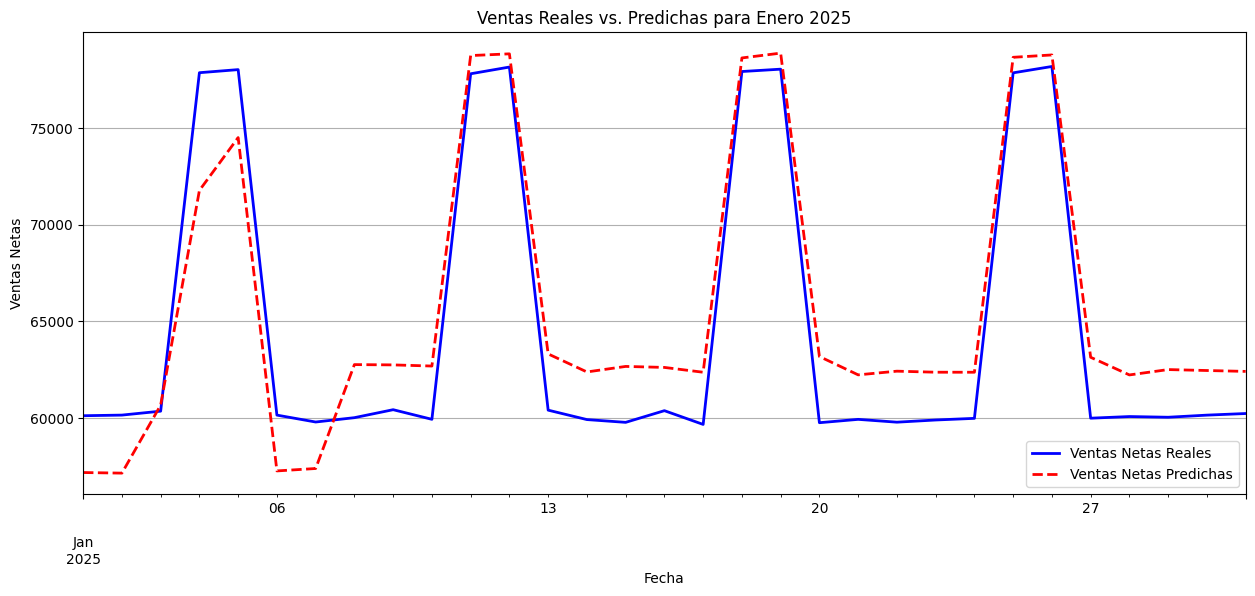

Advertencia: El último conjunto de prueba no contiene datos de Enero de 2025. Ajuste el rango de n_splits.


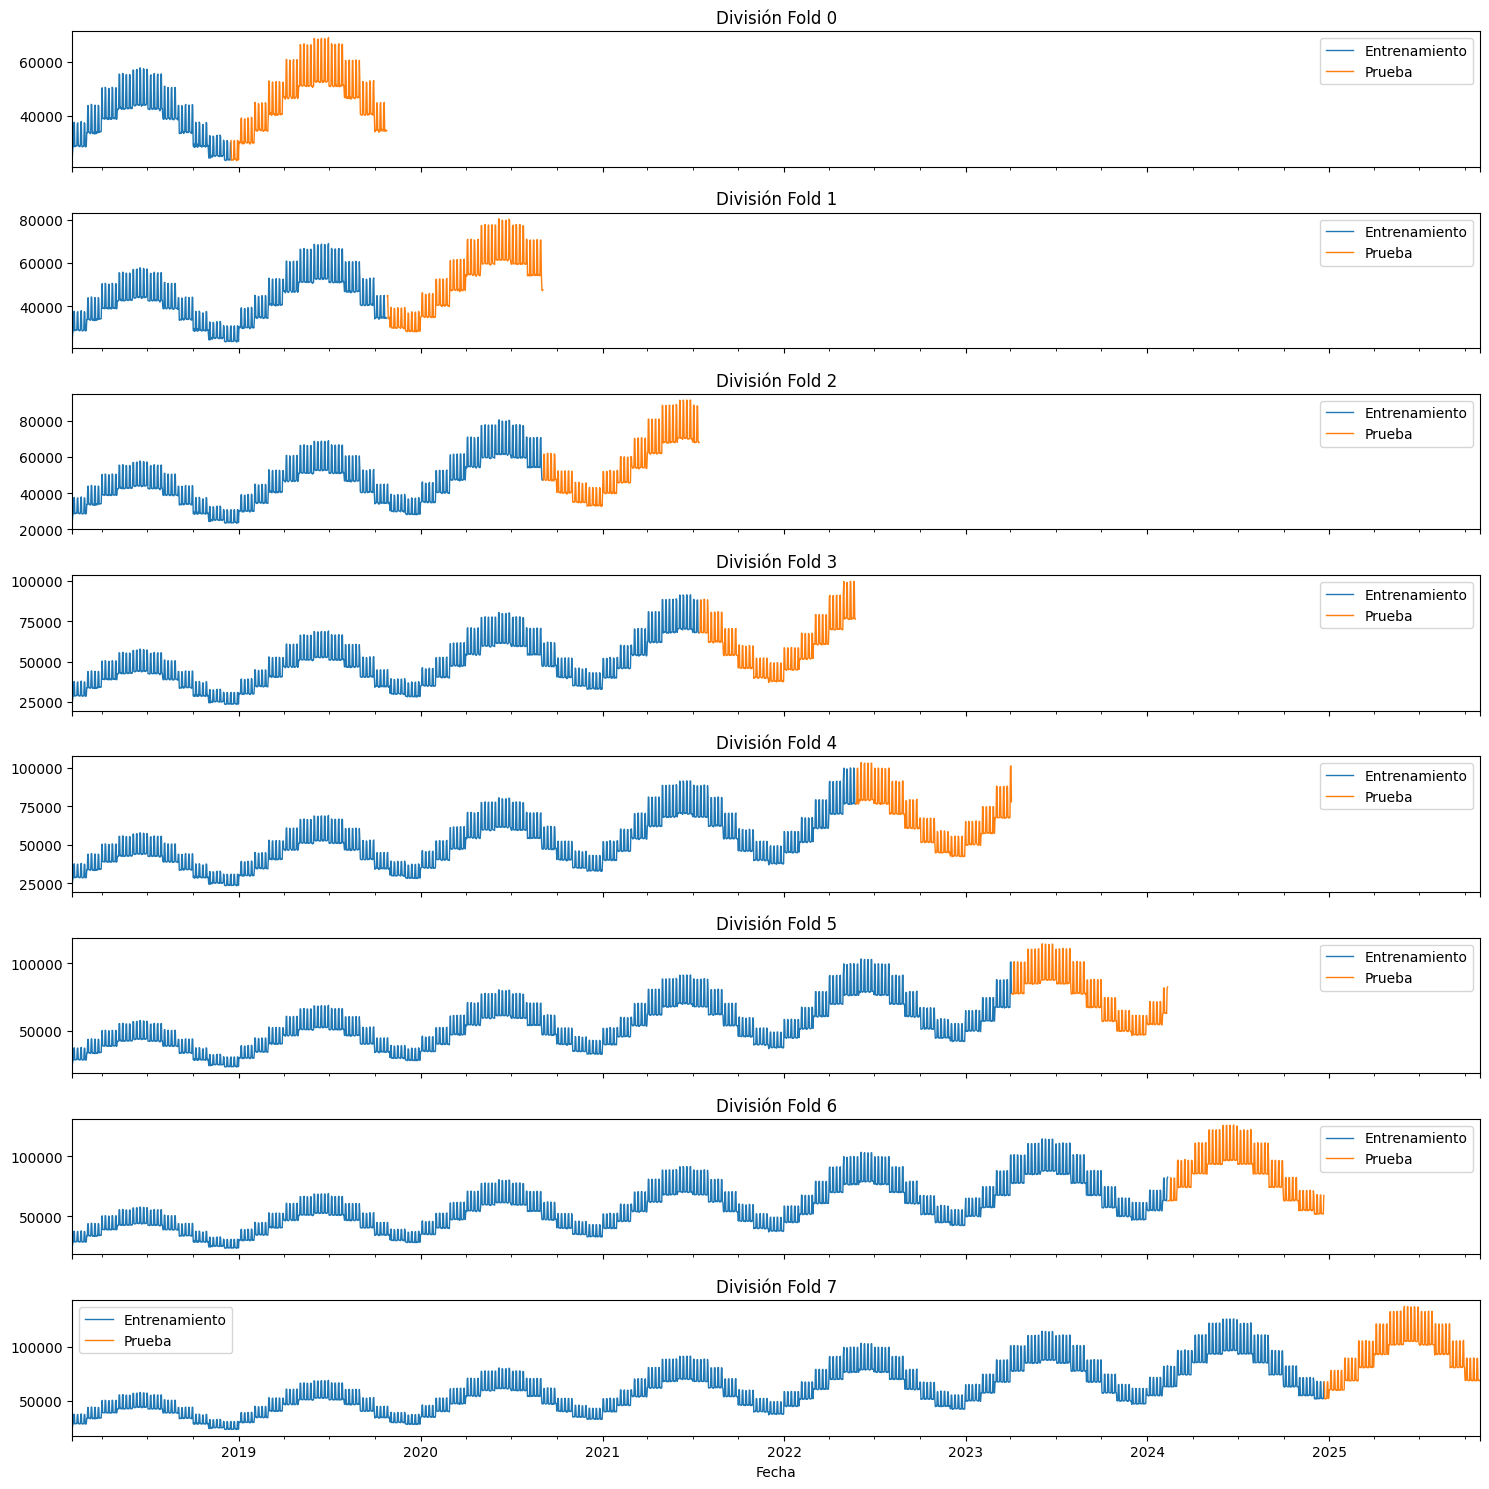

In [ ]:
im
    fold += 1
plt.tight_layout()
plt.show()




--- INICIO DEL ENTRENAMIENTO (8 Folds) ---
Fold 1 → RMSE: 5,088 | R²: 0.7837
Fold 2 → RMSE: 5,548 | R²: 0.8558
Fold 3 → RMSE: 6,062 | R²: 0.8545
Fold 4 → RMSE: 4,203 | R²: 0.9227
Fold 5 → RMSE: 6,157 | R²: 0.8512
Fold 6 → RMSE: 8,974 | R²: 0.7635
Fold 7 → RMSE: 5,268 | R²: 0.9268
Fold 8 → RMSE: 7,757 | R²: 0.8647

--- RESUMEN DE MÉTRICAS ---
RMSE promedio: 6,132
R² promedio: 0.8529


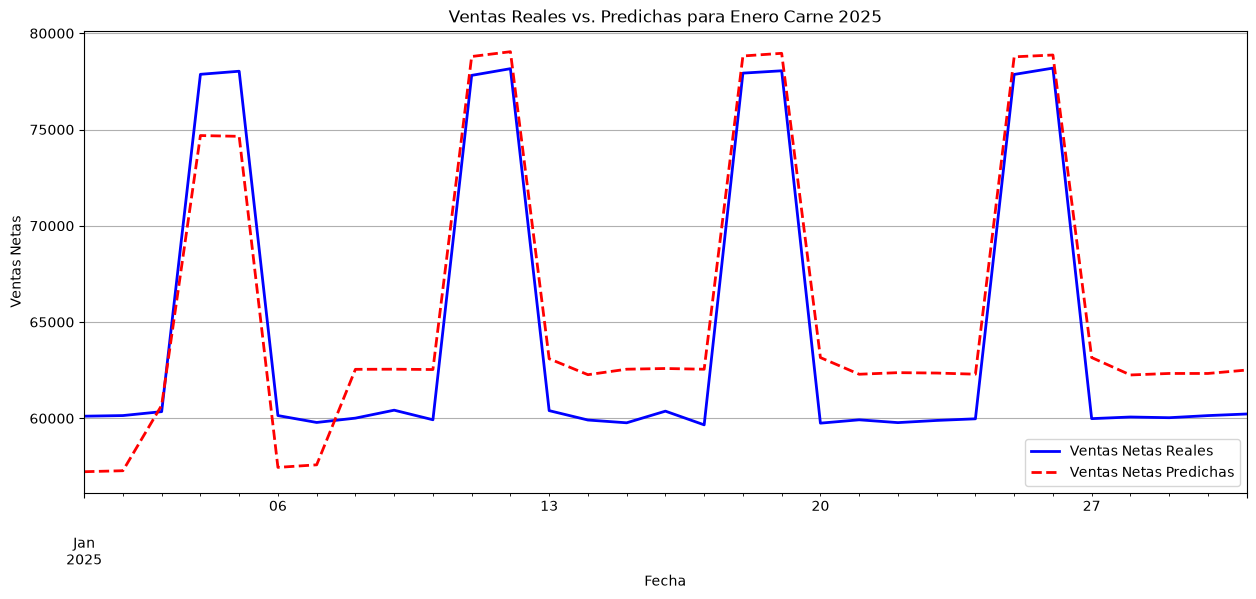

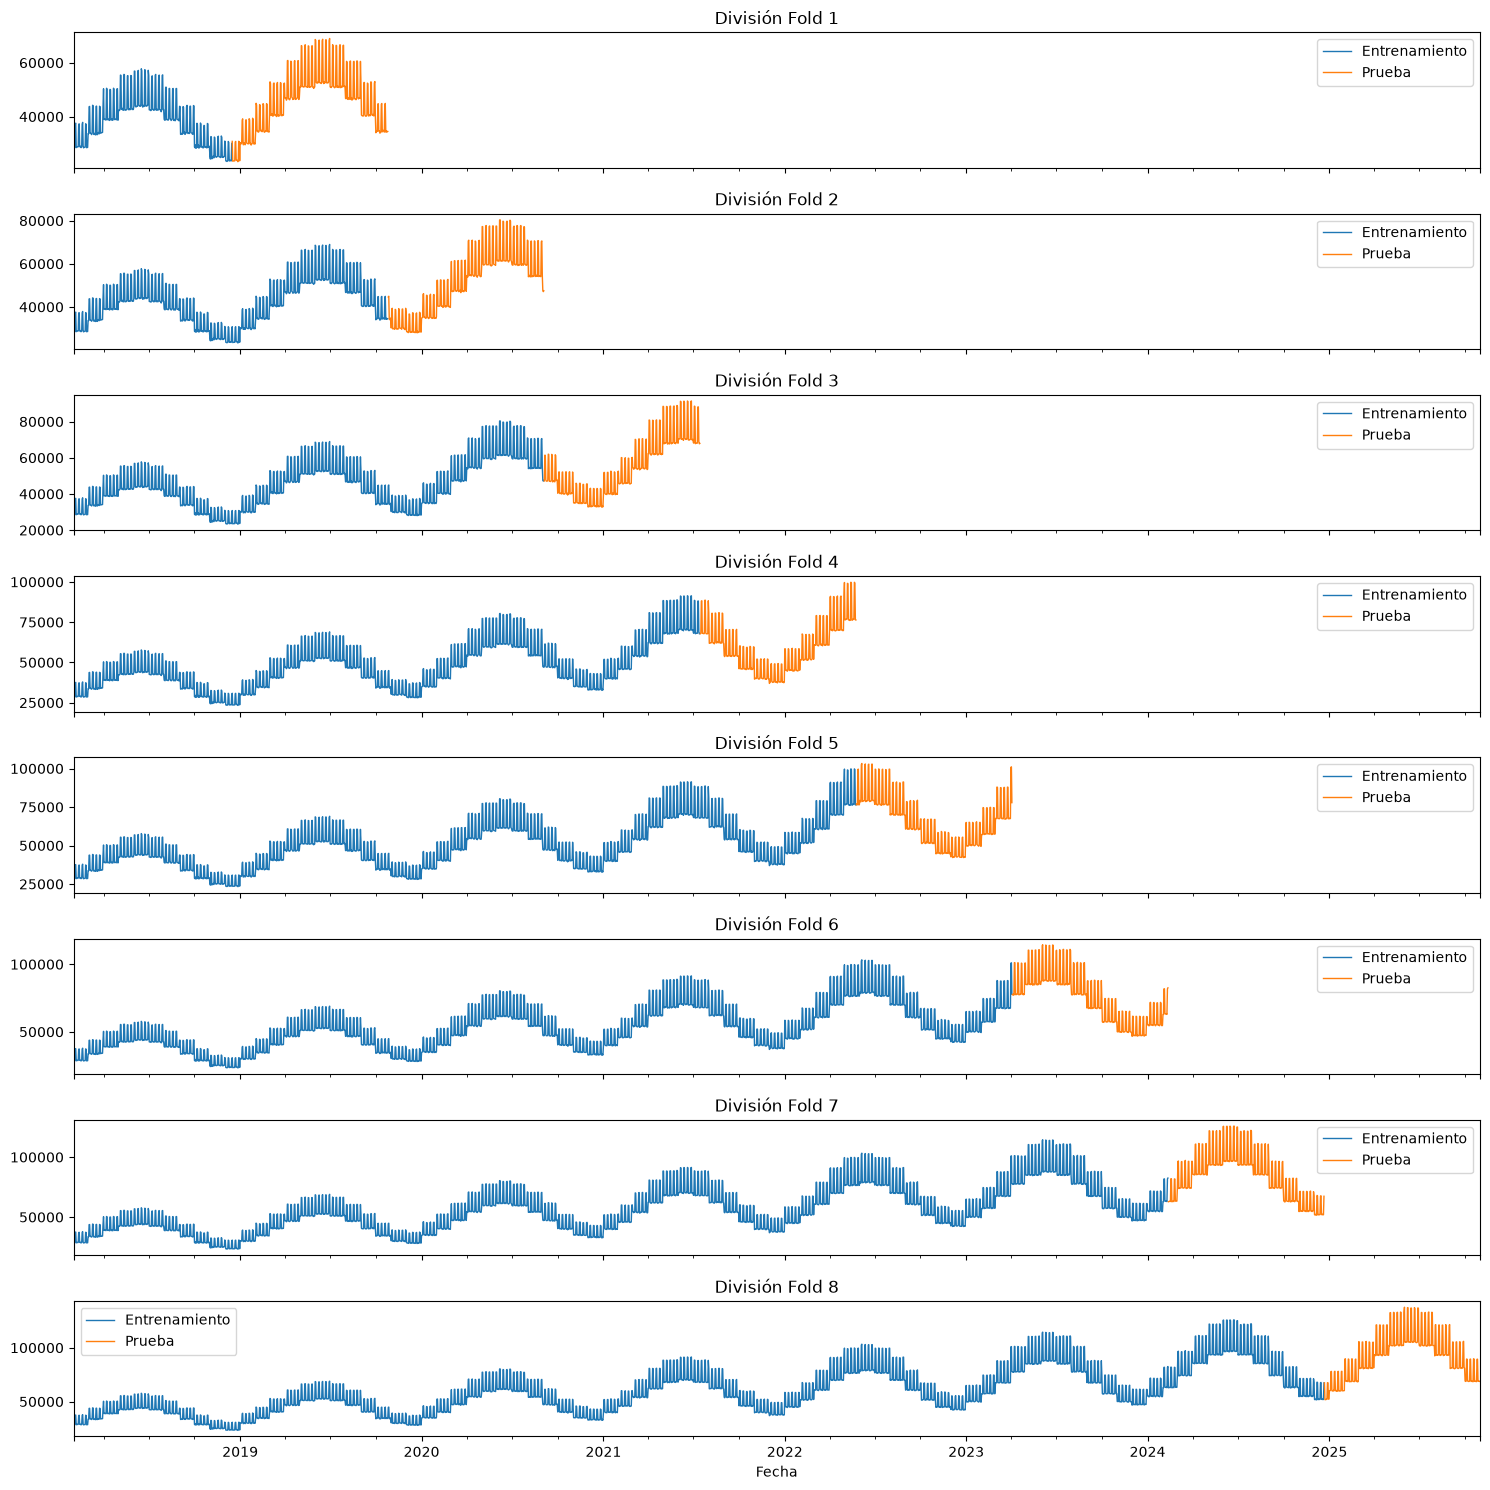

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import XGBRegressor
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit 
from sklearn.metrics import mean_squared_error, r2_score 
from datetime import timedelta 

# --- 1. CONFIGURACIÓN Y USO DE DATOS EN MEMORIA ---

# Garantizar el parseo correcto de la columna Fecha desde el DataFrame cargado
NewDf["Fecha"] = pd.to_datetime(NewDf["Fecha"], dayfirst=True, format='mixed')

# Limpieza y filtrado para el producto "Carne"
df_carne = NewDf[NewDf["Producto"] == "Carne"].copy()
counts = df_carne.groupby("Fecha")["Ventas_Netas"].sum()
pw_clean = pd.DataFrame(counts)
pw_clean["Fecha"] = pd.to_datetime(pw_clean.index)
pw_clean = pw_clean.set_index("Fecha")

# --- 2. FUNCIONES DE INGENIERÍA DE ATRIBUTOS (FEATURE ENGINEERING) ---

def create_attributes(df): 
    """Crea atributos temporales (features) a partir del índice de fecha."""
    df = df.copy() 
    df['día'] = df.index.day 
    df['díadelasemana'] = df.index.dayofweek 
    df['mes'] = df.index.month 
    df['trimestre'] = df.index.quarter 
    df['año'] = df.index.year 
    df['díadelaño'] = df.index.dayofyear 
    return df 

def add_lag_features(df, target='Ventas_Netas', lags=[1, 7, 14, 30]):
    """Crea atributos de lag (retardo) y rolling mean."""
    df = df.copy()
    for lag in lags:
        df[f'{target}_lag{lag}'] = df[target].shift(lag)
    df[f'{target}_rolling7']  = df[target].shift(1).rolling(7).mean()
    df[f'{target}_rolling30'] = df[target].shift(1).rolling(30).mean()
    return df

# Aplicar ingeniería de atributos
pw_clean = create_attributes(pw_clean)
pw_clean = add_lag_features(pw_clean)
pw_clean = pw_clean.dropna()

features = ['día', 'díadelasemana', 'mes', 'trimestre', 'año', 'díadelaño',
            'Ventas_Netas_lag1', 'Ventas_Netas_lag7', 'Ventas_Netas_lag14', 'Ventas_Netas_lag30', 
            'Ventas_Netas_rolling7', 'Ventas_Netas_rolling30']
target = 'Ventas_Netas'

# --- 3. ENTRENAMIENTO Y VALIDACIÓN CON TIME SERIES SPLIT ---

pw_clean = pw_clean.sort_index()
ts_cv = TimeSeriesSplit(n_splits=8)

fold = 0
scores = []      
r2_scores = []   
last_test = None 
xgb_reg = None   

print("\n--- INICIO DEL ENTRENAMIENTO (8 Folds) ---")

for train_idx, val_idx in ts_cv.split(pw_clean):
    fold += 1
    train = pw_clean.iloc[train_idx].copy()
    test  = pw_clean.iloc[val_idx].copy()
    
    # Crear X e Y 
    x_train = train[features]
    y_train = train[target].values.ravel()  
    x_test  = test[features]
    y_test  = test[target].values.ravel()   

    # Hiperparámetros
    xgb_reg = xgb.XGBRegressor(
        booster='gbtree',
        random_state=42,
        n_estimators=1000,
        max_depth=12,
        learning_rate=0.3,  
        reg_lambda=0.001,
        objective='reg:squarederror',
        eval_metric='rmse',
    )
    
    # Entrenamiento 
    xgb_reg.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_test, y_test)], verbose=False)
    
    # Métricas y Predicción
    y_pred = xgb_reg.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    scores.append(rmse)
    r2_scores.append(r2)
    
    print(f"Fold {fold} → RMSE: {rmse:,.0f} | R²: {r2:.4f}")
    
    # --- Guardar el resultado del último Fold para visualización ---
    if fold == ts_cv.n_splits:
        last_test = test.copy()
        last_test['Ventas_Predicha'] = y_pred

print("\n--- RESUMEN DE MÉTRICAS ---")
print(f"RMSE promedio: {np.mean(scores):,.0f}")
print(f"R² promedio: {np.mean(r2_scores):.4f}")

# --- 3.1. VISUALIZACIÓN DE LA PREDICCIÓN VS. REAL (ÚLTIMO TEST SET: Enero 2025) ---

if last_test is not None:
    plt.figure(figsize=(15, 6))
    
    data_enero_2025 = last_test[last_test.index.to_period('M') == '2025-01']
    
    if not data_enero_2025.empty:
        # 1. Plotear los valores reales
        data_enero_2025[target].plot(
            label='Ventas Netas Reales', 
            color='blue', 
            linewidth=2
        )
        
        # 2. Plotear los valores predichos
        data_enero_2025['Ventas_Predicha'].plot(
            label='Ventas Netas Predichas', 
            color='red', 
            linestyle='--', 
            linewidth=2
        )
        
        plt.title('Ventas Reales vs. Predichas para Enero Carne 2025')
        plt.xlabel('Fecha')
        plt.ylabel('Ventas Netas')
        plt.grid(True)
        plt.legend()
        plt.show()
    else:
        print("Advertencia: El último conjunto de prueba no contiene datos de Enero de 2025. Ajuste el rango de n_splits.")

# Gráfico de las divisiones de TimeSeriesSplit 
fig, axs = plt.subplots(8, 1, figsize=(15, 15), sharex=True) 
fold = 0
for train_idx, val_idx in ts_cv.split(pw_clean):
    train = pw_clean.iloc[train_idx]
    test  = pw_clean.iloc[val_idx]
    train[target].plot(ax=axs[fold], lw=1, label="Entrenamiento")
    test[target].plot(ax=axs[fold], lw=1, label="Prueba")
    axs[fold].set_title(f"División Fold {fold + 1}") 
    axs[fold].legend()
    fold += 1
plt.tight_layout()
plt.show()


In [63]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import xgboost as xgb
from datetime import timedelta
from pathlib import Path
from IPython.display import display, HTML

# --- 1. PREPARACIÓN Y USO DE DATOS EN MEMORIA ---

# Parseo correcto de la columna Fecha
NewDf["Fecha"] = pd.to_datetime(NewDf["Fecha"], dayfirst=True, format='mixed')

# Filtrar para el producto "Pollo"
df_pollo = NewDf[NewDf["Producto"] == "Pollo"].copy()
pw_clean = df_pollo.groupby("Fecha")["Ventas_Netas"].sum().to_frame()
pw_clean.sort_index(inplace=True)

def create_features(df):
    df = df.copy()
    df['día'] = df.index.day
    df['díadelasemana'] = df.index.dayofweek
    df['mes'] = df.index.month
    df['trimestre'] = df.index.quarter
    df['año'] = df.index.year
    df['díadelaño'] = df.index.dayofyear
    return df

def add_lags(df):
    df = df.copy()
    for lag in [1, 7, 14, 30]:
        df[f'Ventas_Netas_lag{lag}'] = df['Ventas_Netas'].shift(lag)
    df['Ventas_Netas_rolling7']  = df['Ventas_Netas'].shift(1).rolling(7).mean()
    df['Ventas_Netas_rolling30'] = df['Ventas_Netas'].shift(1).rolling(30).mean()
    return df

features = ['día', 'díadelasemana', 'mes', 'trimestre', 'año', 'díadelaño',
            'Ventas_Netas_lag1', 'Ventas_Netas_lag7', 'Ventas_Netas_lag14', 'Ventas_Netas_lag30', 
            'Ventas_Netas_rolling7', 'Ventas_Netas_rolling30']

# --- 2. DIVISIÓN DE DATOS Y ENTRENAMIENTO ---
full_data = add_lags(create_features(pw_clean)).dropna()

train_data = full_data[full_data.index < '2025-01-01']
test_data = full_data[full_data.index >= '2025-01-01']

xgb_reg = xgb.XGBRegressor(n_estimators=1000, max_depth=12, learning_rate=0.3, random_state=42)
xgb_reg.fit(train_data[features], train_data['Ventas_Netas'])

# Predicciones para la gráfica
train_preds = xgb_reg.predict(train_data[features])
test_preds = xgb_reg.predict(test_data[features])

# --- 3. PROYECCIÓN FUTURA (30 DÍAS) ---
df_proy = pw_clean.copy()
ultima_fecha_real = pw_clean.index.max()

for _ in range(30):
    nueva_fecha = df_proy.index.max() + timedelta(days=1)
    df_proy.loc[nueva_fecha, 'Ventas_Netas'] = np.nan
    
    temp = add_lags(create_features(df_proy))
    X_f = temp.loc[[nueva_fecha], features]
    
    pred = xgb_reg.predict(X_f)[0]
    df_proy.loc[nueva_fecha, 'Ventas_Netas'] = max(0, pred)

proyeccion_nov = df_proy.loc[df_proy.index > ultima_fecha_real].copy()

# --- 4. GRÁFICA INTERACTIVA PLOTLY (Sin nbformat) ---
fig = go.Figure()

# 1. Historia Real
fig.add_trace(go.Scatter(x=pw_clean.index, y=pw_clean['Ventas_Netas'],
                         name='Venta Real', line=dict(color='silver', width=1.5)))

# 2. Ajuste de Entrenamiento (Hasta Dic 2024)
fig.add_trace(go.Scatter(x=train_data.index, y=train_preds,
                         name='Ajuste Entrenamiento (Pre-2025)', line=dict(color='blue', width=1, dash='dot')))

# 3. Testeo / Validación (Enero 2025 en adelante)
fig.add_trace(go.Scatter(x=test_data.index, y=test_preds,
                         name='Validación (Test 2025)', line=dict(color='red', width=2)))

# 4. Proyección Futura
ultimo_real = pw_clean.tail(1)
x_p = pd.concat([ultimo_real.index.to_series(), proyeccion_nov.index.to_series()])
y_p = pd.concat([ultimo_real['Ventas_Netas'], proyeccion_nov['Ventas_Netas']])

fig.add_trace(go.Scatter(x=x_p, y=y_p,
                         name='Proyección (Noviembre 2025)', line=dict(color='green', width=4)))

# Configuración del Layout
fig.update_layout(
    title="Pollo: Historia, Validación 2025 y Proyección Noviembre",
    xaxis_title="Fecha", yaxis_title="Ventas Netas",
    template="plotly_white", hovermode="x unified"
)

# RENDERIZADO DIRECTO EN HTML (Salta la validación de nbformat)
display(HTML(fig.to_html(include_plotlyjs='cdn')))

# --- 5. CONSOLIDACIÓN Y EXPORTACIÓN ---
df_export = pw_clean.copy()
df_export.columns = ['Venta_Real']

df_export.loc[train_data.index, 'Entrenamiento_Ajuste'] = train_preds
df_export.loc[test_data.index, 'Validacion_Test_2025'] = test_preds

for fecha_f in proyeccion_nov.index:
    df_export.loc[fecha_f, 'Proyeccion_Noviembre'] = proyeccion_nov.loc[fecha_f, 'Ventas_Netas']

df_export = df_export.round(0)

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

nombre_final_excel = output_dir / "Analisis_Final_Ventas_Pollo_Final.xlsx"
df_export.to_excel(nombre_final_excel, index_label='Fecha')

print(f"¡Excel generado con éxito!")
print(f"📁 Ruta: {nombre_final_excel}")
print(f"Columnas incluidas: Venta_Real, Entrenamiento_Ajuste, Validacion_Test_2025, Proyeccion_Noviembre")

¡Excel generado con éxito!
📁 Ruta: ../data/processed/Analisis_Final_Ventas_Pollo_Final.xlsx
Columnas incluidas: Venta_Real, Entrenamiento_Ajuste, Validacion_Test_2025, Proyeccion_Noviembre


In [65]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import xgboost as xgb
from datetime import timedelta
from pathlib import Path
from IPython.display import display, HTML

# --- 1. PREPARACIÓN Y USO DE DATOS EN MEMORIA ---

# Parseo correcto de la columna Fecha desde el DataFrame cargado
NewDf["Fecha"] = pd.to_datetime(NewDf["Fecha"], dayfirst=True, format='mixed')

# Filtrar para el producto "Carne"
df_carne = NewDf[NewDf["Producto"] == "Carne"].copy()
pw_clean = df_carne.groupby("Fecha")["Ventas_Netas"].sum().to_frame()
pw_clean.sort_index(inplace=True)

def create_features(df):
    df = df.copy()
    df['día'] = df.index.day
    df['díadelasemana'] = df.index.dayofweek
    df['mes'] = df.index.month
    df['trimestre'] = df.index.quarter
    df['año'] = df.index.year
    df['díadelaño'] = df.index.dayofyear
    return df

def add_lags(df):
    df = df.copy()
    for lag in [1, 7, 14, 30]:
        df[f'Ventas_Netas_lag{lag}'] = df['Ventas_Netas'].shift(lag)
    df['Ventas_Netas_rolling7']  = df['Ventas_Netas'].shift(1).rolling(7).mean()
    df['Ventas_Netas_rolling30'] = df['Ventas_Netas'].shift(1).rolling(30).mean()
    return df

features = ['día', 'díadelasemana', 'mes', 'trimestre', 'año', 'díadelaño',
            'Ventas_Netas_lag1', 'Ventas_Netas_lag7', 'Ventas_Netas_lag14', 'Ventas_Netas_lag30', 
            'Ventas_Netas_rolling7', 'Ventas_Netas_rolling30']

# --- 2. DIVISIÓN DE DATOS Y ENTRENAMIENTO ---
full_data = add_lags(create_features(pw_clean)).dropna()

train_data = full_data[full_data.index < '2025-01-01']
test_data = full_data[full_data.index >= '2025-01-01']

xgb_reg = xgb.XGBRegressor(n_estimators=1000, max_depth=12, learning_rate=0.3, random_state=42)
xgb_reg.fit(train_data[features], train_data['Ventas_Netas'])

# Predicciones para la gráfica
train_preds = xgb_reg.predict(train_data[features])
test_preds = xgb_reg.predict(test_data[features])

# --- 3. PROYECCIÓN FUTURA (30 DÍAS) ---
df_proy = pw_clean.copy()
ultima_fecha_real = pw_clean.index.max()

for _ in range(30):
    nueva_fecha = df_proy.index.max() + timedelta(days=1)
    df_proy.loc[nueva_fecha, 'Ventas_Netas'] = np.nan
    
    temp = add_lags(create_features(df_proy))
    X_f = temp.loc[[nueva_fecha], features]
    
    pred = xgb_reg.predict(X_f)[0]
    df_proy.loc[nueva_fecha, 'Ventas_Netas'] = max(0, pred)

proyeccion_nov = df_proy.loc[df_proy.index > ultima_fecha_real].copy()

# --- 4. GRÁFICA INTERACTIVA PLOTLY (Sin dependencia de nbformat) ---
fig = go.Figure()

# 1. Historia Real
fig.add_trace(go.Scatter(x=pw_clean.index, y=pw_clean['Ventas_Netas'],
                         name='Venta Real', line=dict(color='silver', width=1.5)))

# 2. Ajuste de Entrenamiento (Hasta Dic 2024)
fig.add_trace(go.Scatter(x=train_data.index, y=train_preds,
                         name='Ajuste Entrenamiento (Pre-2025)', line=dict(color='blue', width=1, dash='dot')))

# 3. Testeo / Validación (Enero 2025 en adelante)
fig.add_trace(go.Scatter(x=test_data.index, y=test_preds,
                         name='Validación (Test 2025)', line=dict(color='red', width=2)))

# 4. Proyección Futura
ultimo_real = pw_clean.tail(1)
x_p = pd.concat([ultimo_real.index.to_series(), proyeccion_nov.index.to_series()])
y_p = pd.concat([ultimo_real['Ventas_Netas'], proyeccion_nov['Ventas_Netas']])

fig.add_trace(go.Scatter(x=x_p, y=y_p,
                         name='Proyección (Noviembre 2025)', line=dict(color='green', width=4)))

# Configuración del Layout
fig.update_layout(
    title="Carne: Historia, Validación 2025 y Proyección Noviembre",
    xaxis_title="Fecha", yaxis_title="Ventas Netas",
    template="plotly_white", hovermode="x unified"
)

# Renderizado HTML directo dentro del cuaderno
display(HTML(fig.to_html(include_plotlyjs='cdn')))

# --- 5. CONSOLIDACIÓN Y EXPORTACIÓN A EXCEL ---
df_export = pw_clean.copy()
df_export.columns = ['Venta_Real']

df_export.loc[train_data.index, 'Entrenamiento_Ajuste'] = train_preds
df_export.loc[test_data.index, 'Validacion_Test_2025'] = test_preds

for fecha_f in proyeccion_nov.index:
    df_export.loc[fecha_f, 'Proyeccion_Noviembre'] = proyeccion_nov.loc[fecha_f, 'Ventas_Netas']

df_export = df_export.round(0)

# Asegurar carpeta de salida
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

nombre_final_excel = output_dir / "Analisis_Final_Ventas_Carne_Final.xlsx"
df_export.to_excel(nombre_final_excel, index_label='Fecha')

print(f"¡Excel generado con éxito!")
print(f"📁 Ruta: {nombre_final_excel}")
print(f"Columnas incluidas: Venta_Real, Entrenamiento_Ajuste, Validacion_Test_2025, Proyeccion_Noviembre")

¡Excel generado con éxito!
📁 Ruta: ../data/processed/Analisis_Final_Ventas_Carne_Final.xlsx
Columnas incluidas: Venta_Real, Entrenamiento_Ajuste, Validacion_Test_2025, Proyeccion_Noviembre
